# 03 - Multivariate analysis and machine learning for NMR oils

This notebook combines exploratory, statistical, multivariate and machine-learning analyses of the processed NMR oil dataset.


## Workflow

1. Load the processed NMR dataset.
2. Select NMR intensity variables and the oil-type label.
3. Screen NMR variables for oil-type differences.
4. Explore discriminative signals with distribution plots, correlations and pairwise comparisons.
5. Standardize the NMR variables and compare mean standardized oil profiles.
6. Perform PCA and interpret scores, loadings and the biplot.
7. Apply K-means clustering to the PCA representation.
8. Evaluate KNN with "leave one manufacturer out" validation.
9. Compare all NMR signals with reduced PCA loading feature sets.
10. Test whether classification depends on one dominant NMR signal.

In [1]:
from itertools import combinations
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import kruskal, ttest_ind
from statsmodels.stats.multitest import multipletests

from sklearn.impute import KNNImputer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import (GridSearchCV, GroupKFold, LeaveOneGroupOut, train_test_split)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, 
    adjusted_rand_score,
    balanced_accuracy_score, 
    classification_report, 
    confusion_matrix, 
    f1_score, 
    silhouette_score)

warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak")

pd.set_option("display.max_columns", None)

In [2]:
from pathlib import Path

PROJECT_DIR =Path(".")
FIGURES_DIR = PROJECT_DIR / "diagrams" / "03"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(FIGURES_DIR)

diagrams/03


## 1. Load the processed dataset

In [3]:
PROJECT_DIR = Path(".")

PROCESSED_DATA_PATH = (PROJECT_DIR / "data" / "processed" / "oils_processed.csv")

FALLBACK_PATH = Path("../oils_processed.csv")

if PROCESSED_DATA_PATH.exists():
    data_path = PROCESSED_DATA_PATH
elif FALLBACK_PATH.exists():
    data_path = FALLBACK_PATH
else:
    raise FileNotFoundError("Processed dataset not found. Run 01_data_preparation.ipynb first.")

data = pd.read_csv(data_path)

print(f"Loaded file: {data_path}")
print(f"Dataset shape: {data.shape}")
data.head()

Loaded file: data/processed/oils_processed.csv
Dataset shape: (149, 28)


,Primary ID,Date,Oil type,Manufacturer,Batch number,Spectra number,0.88 ppm,0.89 ppm,0.90 ppm,0.98 ppm,1.31 ppm,1.36 ppm,1.61 ppm,1.68 ppm,2.05 ppm,2.01 ppm,2.19 ppm,2.31 ppm,2.77 ppm,4.14 ppm,4.29 ppm,5.12 ppm,5.26 ppm,5.34 ppm,5.43 ppm,5.69 ppm,6.05 ppm,6.45 ppm
0,1,2025-10-07,Amaranth oil,A,43739,1,125.47,15.67,12.34,11.18,5306.83,565.27,837.44,73.93,537.41,526.74,12.03,605.74,289.95,212.43,207.07,6.50,98.21,690.85,15.09,0.17,0.14,0.34
1,2,2025-10-07,Amaranth oil,A,43739,2,118.10,12.61,13.60,10.30,4961.43,543.99,798.57,73.89,493.14,559.02,10.17,576.95,278.62,202.45,200.15,6.18,93.73,657.26,14.80,0.16,0.13,0.34
2,3,2025-10-08,Amaranth oil,A,43739,3,120.78,14.86,12.87,10.92,5138.00,565.93,828.82,72.39,523.22,511.93,10.83,593.72,288.63,204.00,204.26,6.55,95.49,674.88,16.99,0.23,0.13,0.32
3,4,2025-10-10,Amaranth oil,B,43466,4,123.53,13.89,13.74,10.57,5255.57,534.17,828.79,85.30,532.51,511.78,10.76,586.82,281.73,207.87,197.60,5.95,95.18,658.60,14.73,0.13,0.10,0.25
4,5,2025-11-02,Amaranth oil,B,43466,5,131.93,14.88,15.07,11.60,5660.95,594.31,886.85,88.52,570.69,605.27,11.31,621.07,291.22,221.07,210.26,6.17,98.52,702.16,19.60,0.14,0.21,0.22


## 2. Select NMR variables and target label

Only numerical NMR measurements are used as model features. Metadata such as `Primary ID`, `Spectra number` and manufacturer information are excluded.

In [4]:
nmr_columns = [column for column in data.columns if "ppm" in column.lower()]

X = data[nmr_columns].copy()
y = data["Oil type"].copy()

print(f"Number of samples: {X.shape[0]}")
print(f"Number of NMR variables: {X.shape[1]}")
print("\nClass distribution:")
display(y.value_counts())

X.head()

Number of samples: 149
Number of NMR variables: 22

Class distribution:


Oil type
Amaranth oil         50
Sea buckthorn oil    50
Pomegranate oil      49
Name: count, dtype: int64

,0.88 ppm,0.89 ppm,0.90 ppm,0.98 ppm,1.31 ppm,1.36 ppm,1.61 ppm,1.68 ppm,2.05 ppm,2.01 ppm,2.19 ppm,2.31 ppm,2.77 ppm,4.14 ppm,4.29 ppm,5.12 ppm,5.26 ppm,5.34 ppm,5.43 ppm,5.69 ppm,6.05 ppm,6.45 ppm
0,125.47,15.67,12.34,11.18,5306.83,565.27,837.44,73.93,537.41,526.74,12.03,605.74,289.95,212.43,207.07,6.50,98.21,690.85,15.09,0.17,0.14,0.34
1,118.10,12.61,13.60,10.30,4961.43,543.99,798.57,73.89,493.14,559.02,10.17,576.95,278.62,202.45,200.15,6.18,93.73,657.26,14.80,0.16,0.13,0.34
2,120.78,14.86,12.87,10.92,5138.00,565.93,828.82,72.39,523.22,511.93,10.83,593.72,288.63,204.00,204.26,6.55,95.49,674.88,16.99,0.23,0.13,0.32
3,123.53,13.89,13.74,10.57,5255.57,534.17,828.79,85.30,532.51,511.78,10.76,586.82,281.73,207.87,197.60,5.95,95.18,658.60,14.73,0.13,0.10,0.25
4,131.93,14.88,15.07,11.60,5660.95,594.31,886.85,88.52,570.69,605.27,11.31,621.07,291.22,221.07,210.26,6.17,98.52,702.16,19.60,0.14,0.21,0.22


## 3. Exploratory analysis of discriminative NMR signals

This section first identifies NMR variables that differ among oil types and then visualizes their distributions and relationships.


### 3.1 Screening NMR variables with the Kruskal-Wallis test

The Kruskal-Wallis test compares the distributions of each NMR variable across the three oil types. The Benjamini-Hochberg procedure controls the false-discovery rate across multiple tests.

p < 0.05 is considered a statistically significant result.


In [5]:
screening_results = []
oil_types = data["Oil type"].dropna().unique()

for column in nmr_columns:
    groups = [data.loc[data["Oil type"] == oil_type, column].dropna() for oil_type in oil_types]

    # Retain groups containing at least two observations.
    valid_groups = [group for group in groups if len(group) >= 2]

    if len(valid_groups) < 2:
        statistic = np.nan
        p_value = np.nan
    else:
        try:
            statistic, p_value = kruskal(*valid_groups)
        except ValueError:
            # This occurs when all observations are identical.
            statistic = 0.0
            p_value = 1.0

    screening_results.append({"NMR variable": column, 
                              "Kruskal-Wallis statistic": statistic,
                              "p-value": p_value})

screening_results = pd.DataFrame(screening_results)

valid_p_values = screening_results["p-value"].notna()
screening_results["FDR-adjusted p-value"] = np.nan

# Benjamini–Hochberg correction: Since the test is performed 
# separately for multiple ppm values, the risk of accidentally obtaining a significant result increases.
screening_results.loc[valid_p_values,"FDR-adjusted p-value"] = multipletests(screening_results
                                                               .loc[valid_p_values,"p-value"],method="fdr_bh")[1]

screening_results = (screening_results
                    .sort_values(["FDR-adjusted p-value", "Kruskal-Wallis statistic"],
                    ascending=[True, False])
                    .reset_index(drop=True))

display(screening_results.head(10))


,NMR variable,Kruskal-Wallis statistic,p-value,FDR-adjusted p-value
0,5.12 ppm,131.630347,2.611159e-29,5.416620e-29
1,2.77 ppm,131.586644,2.668845e-29,5.416620e-29
2,0.89 ppm,131.568502,2.693164e-29,5.416620e-29
3,1.68 ppm,131.567786,2.694128e-29,5.416620e-29
4,0.88 ppm,131.563013,2.700565e-29,5.416620e-29
5,2.01 ppm,131.558002,2.707341e-29,5.416620e-29
6,1.36 ppm,131.557763,2.707664e-29,5.416620e-29
7,2.05 ppm,131.557763,2.707664e-29,5.416620e-29
8,5.43 ppm,131.557763,2.707664e-29,5.416620e-29
9,5.34 ppm,131.557524,2.707987e-29,5.416620e-29


In [6]:
top_features = (screening_results.dropna(subset=["FDR-adjusted p-value"]).head(3)["NMR variable"].tolist())

print("NMR variables selected for detailed visualization:")
for feature in top_features:
    print(f"- {feature}")


NMR variables selected for detailed visualization:
- 5.12 ppm
- 2.77 ppm
- 0.89 ppm


### 3.2 Boxplots

The boxplots compare medians, interquartile ranges, spread and potential outliers among oil types for the most discriminative NMR variables.


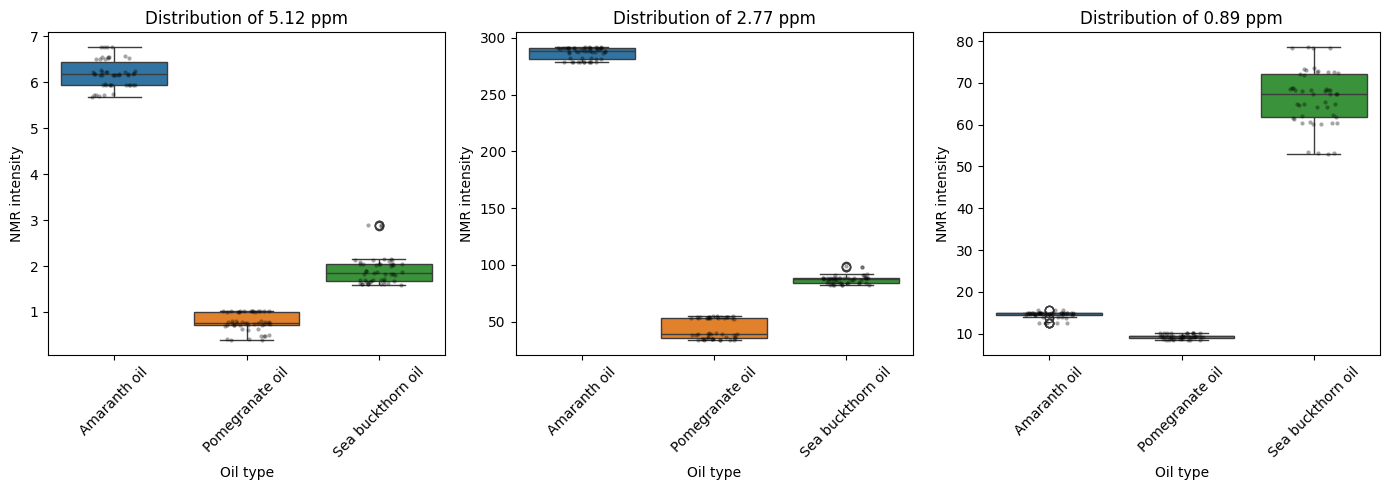

In [7]:
selected_features = top_features[:3]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, column in zip(axes, selected_features):

    sns.boxplot(data=data, x="Oil type", y=column, hue="Oil type", ax=ax)

    sns.stripplot(data=data, x="Oil type", y=column, color="black", alpha=0.35, jitter=0.18, size=3, ax=ax)

    ax.set_xlabel("Oil type")
    ax.set_ylabel("NMR intensity")
    ax.set_title(f"Distribution of {column}")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Note**
- The three selected NMR variables showed clearly different median intensities across oil types.
- The interquartile ranges showed little or no overlap, indicating strong discriminatory potential.
- At 5.12 ppm, Amaranth oil had the highest median, Pomegranate oil the lowest, and Sea buckthorn oil intermediate values.
- At 2.77 ppm, the three oil groups were completely separated, with Amaranth oil showing the highest intensities.
- At 0.89 ppm, Sea buckthorn oil was clearly separated from the other groups and showed the largest within-group variability.
- A few potential outliers were observed, particularly for Sea buckthorn oil at 5.12 ppm and 2.77 ppm, and for Amaranth oil at 0.89 ppm.
- These points should not be removed automatically because they may represent genuine sample variability.

### 3.3 Violin plot

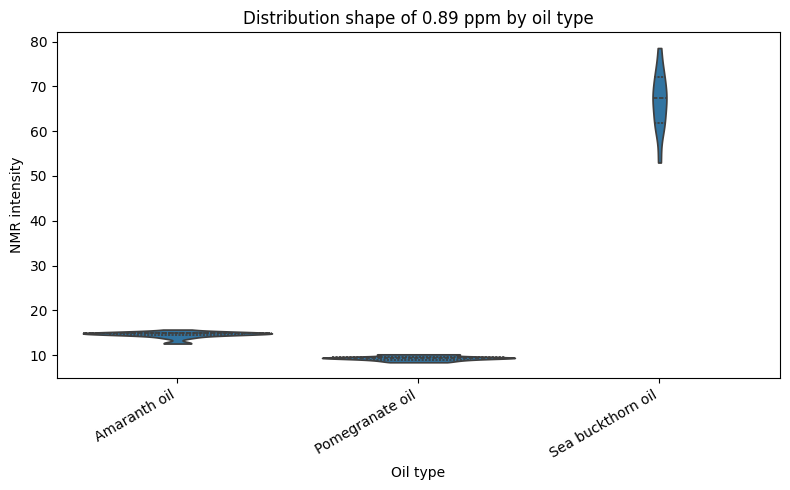

In [8]:
selected_feature = top_features[2]

plt.figure(figsize=(8, 5))

sns.violinplot(data=data, x="Oil type", y=selected_feature, inner="quartile", cut=0)

plt.xlabel("Oil type")
plt.ylabel("NMR intensity")
plt.title(f"Distribution shape of {selected_feature} by oil type")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### 3.4 Histogram and density plot

The histogram shows the observed frequency distribution, while the density plot compares smoothed oil-specific distributions. Multimodality can arise when chemically different oil groups occupy different intensity ranges.


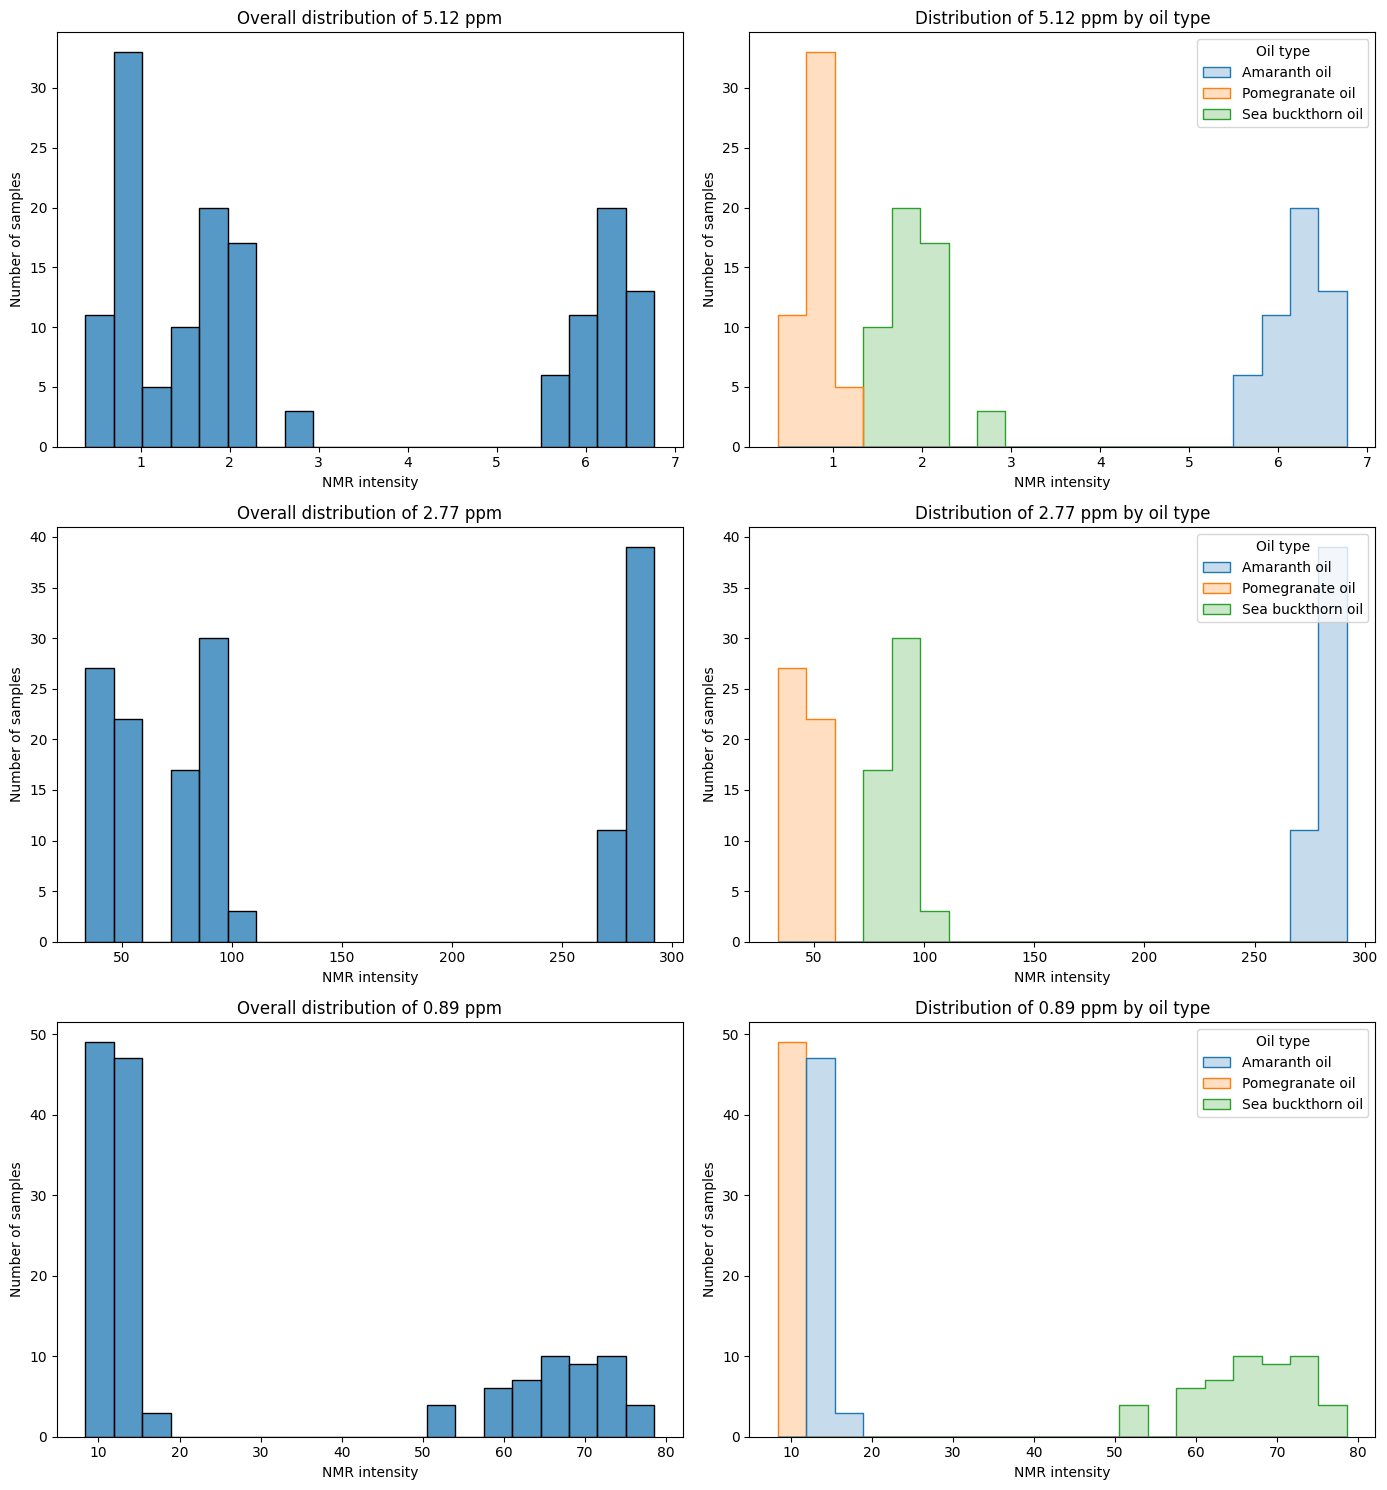

In [9]:
# Select the three highest-ranked NMR variables
selected_features = top_features[:3]

# Create 3 rows and 2 columns
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

for row, feature in enumerate(selected_features):

    # Overall distribution
    sns.histplot(data=data, x=feature, bins=20, ax=axes[row, 0])

    axes[row, 0].set_xlabel("NMR intensity")
    axes[row, 0].set_ylabel("Number of samples")
    axes[row, 0].set_title(f"Overall distribution of {feature}")

    # Distribution separated by oil type
    sns.histplot(data=data, x=feature, hue="Oil type", bins=20, element="step", ax=axes[row, 1])

    axes[row, 1].set_xlabel("NMR intensity")
    axes[row, 1].set_ylabel("Number of samples")
    axes[row, 1].set_title(f"Distribution of {feature} by oil type")

plt.tight_layout()
plt.show()

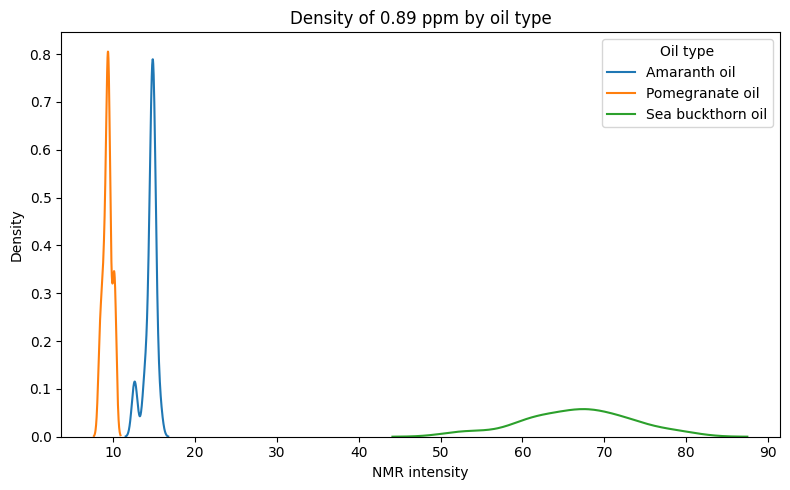

In [10]:
plt.figure(figsize=(8, 5))

sns.kdeplot(data=data, x=selected_feature, hue="Oil type", common_norm=False, fill=False)

plt.xlabel("NMR intensity")
plt.ylabel("Density")
plt.title(f"Density of {selected_feature} by oil type")
plt.tight_layout()
plt.show()


- The pooled distributions were multimodal because the dataset contained three distinct oil groups.
- At 5.12 ppm and 2.77 ppm, the oil-specific distributions showed almost no overlap, indicating strong univariate discriminatory potential.
- The 2.77 ppm signal provided the clearest separation among all three oil types.
- At 0.89 ppm, Sea buckthorn oil was completely separated from the other groups, while Amaranth and Pomegranate oils were closer but still largely distinguishable.
- Some within-group distributions showed slight skewness or secondary peaks, which may reflect natural heterogeneity or repeated values introduced during imputation.

### 3.5 Correlation heatmap

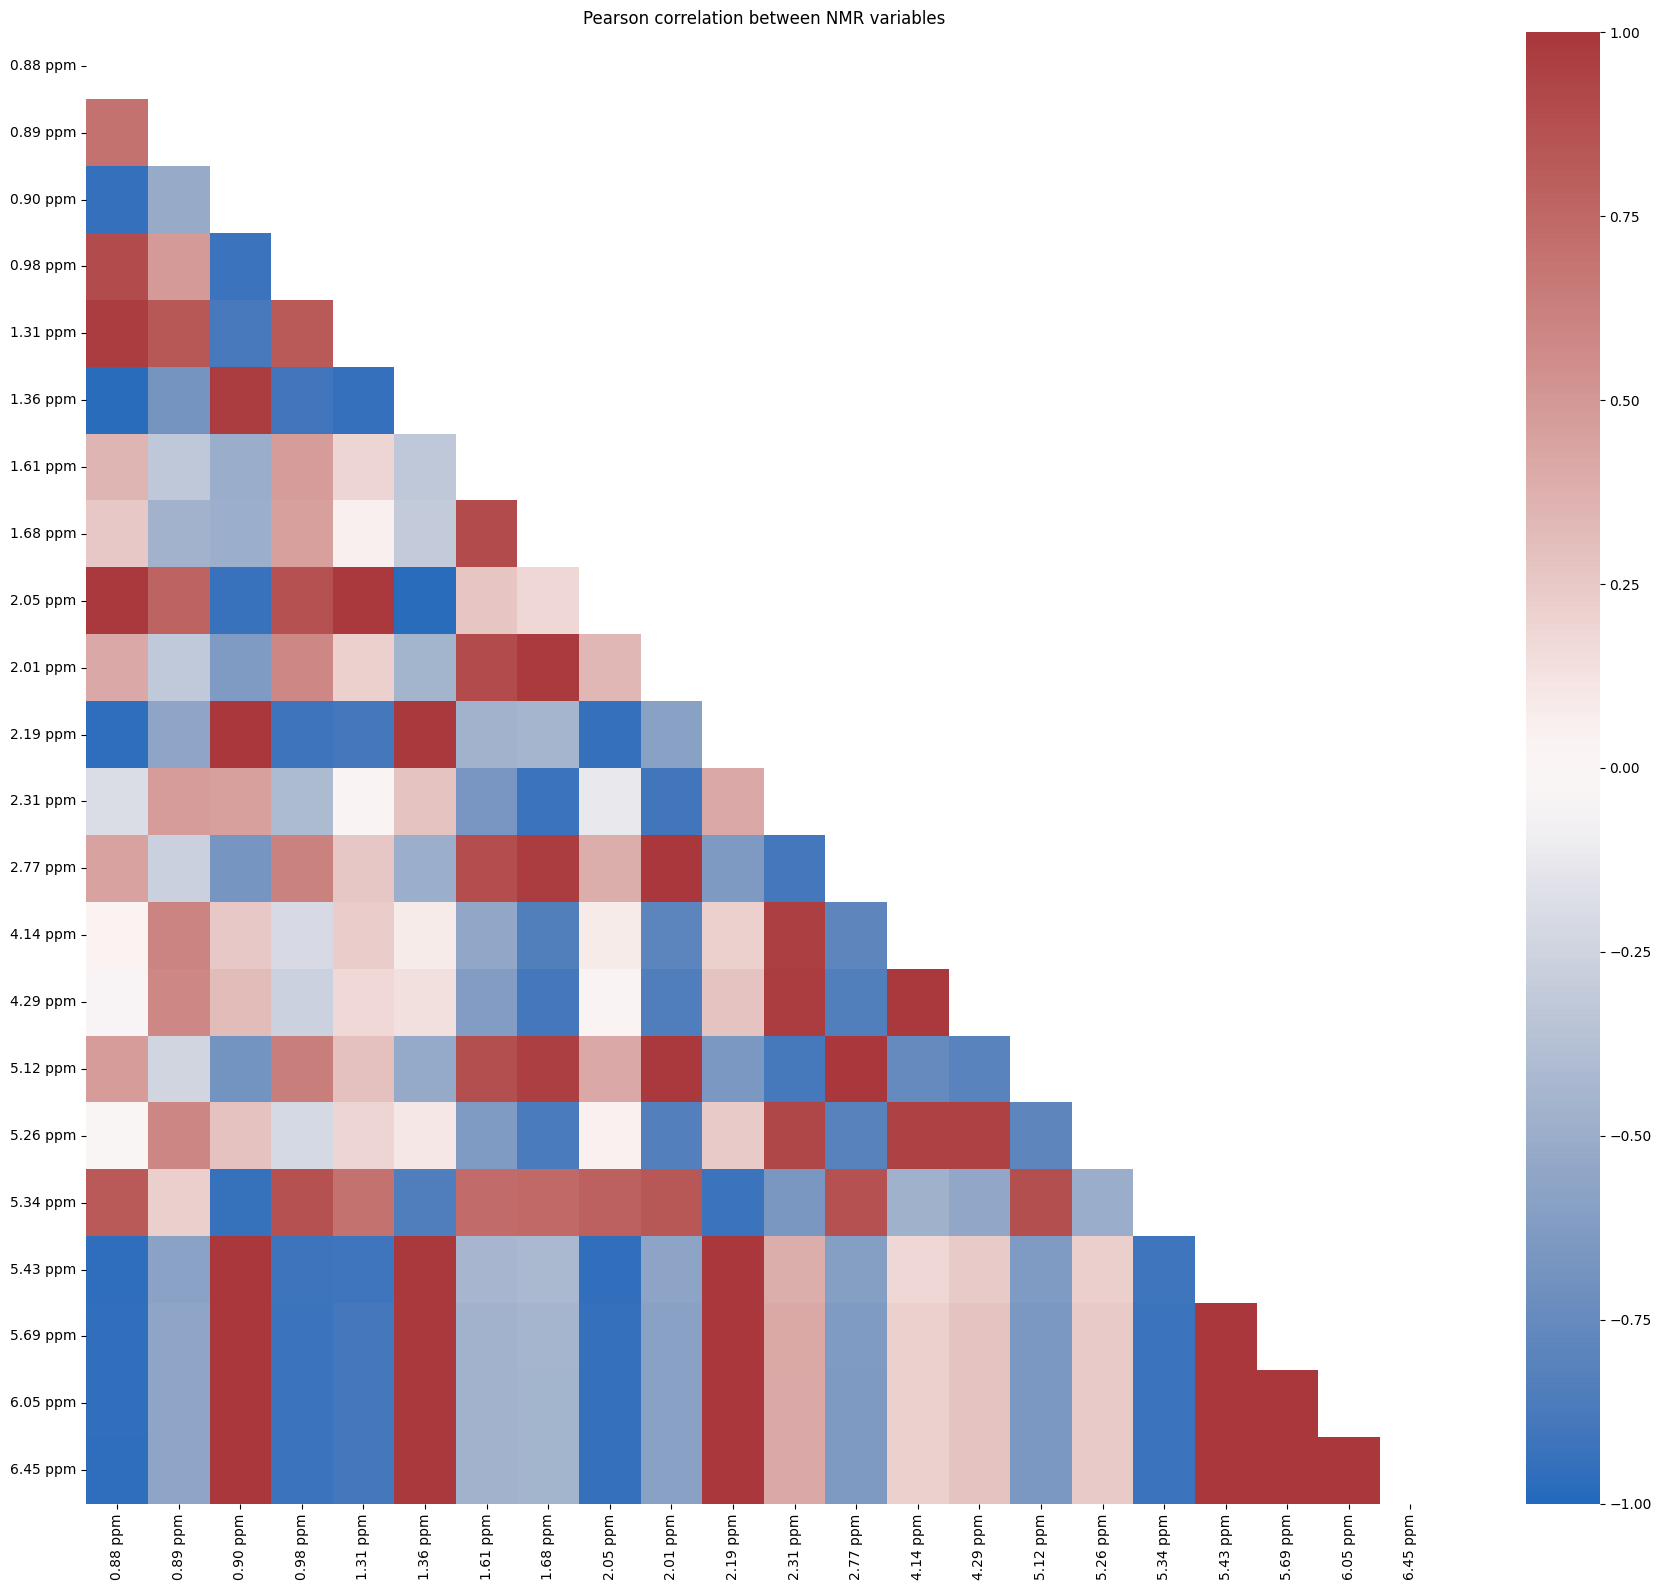

In [11]:
correlation_data = X.corr()

heatmap_mask = np.triu(np.ones_like(correlation_data, dtype=bool))

plt.figure(figsize=(18, 16))

sns.heatmap(correlation_data, mask=heatmap_mask, cmap="vlag", center=0, vmin=-1, vmax=1)

plt.title("Pearson correlation between NMR variables")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


In [12]:
upper_triangle = correlation_data.where(np.triu(np.ones(correlation_data.shape), k=1).astype(bool))

correlation_pairs = (upper_triangle .stack() .reset_index())

correlation_pairs.columns = ["Variable 1", "Variable 2", "correlation"]

correlation_pairs["absolute correlation"] = (correlation_pairs["correlation"].abs())

strong_correlations = (correlation_pairs[correlation_pairs["absolute correlation"] >= 0.85] 
                       .sort_values("absolute correlation", ascending=False)
                       .reset_index(drop=True))

display(strong_correlations)

,Variable 1,Variable 2,correlation,absolute correlation
0,2.19 ppm,6.05 ppm,0.999939,0.999939
1,2.19 ppm,6.45 ppm,0.999801,0.999801
2,5.69 ppm,6.05 ppm,0.999756,0.999756
3,6.05 ppm,6.45 ppm,0.999748,0.999748
4,2.19 ppm,5.69 ppm,0.999686,0.999686
...,...,...,...,...
81,0.98 ppm,5.34 ppm,0.872214,0.872214
82,0.98 ppm,2.05 ppm,0.872182,0.872182
83,1.68 ppm,5.26 ppm,-0.871982,0.871982
84,2.77 ppm,5.34 ppm,0.869223,0.869223


- Several groups of NMR variables showed strong positive correlations, indicating overlapping or redundant spectral information.
- The strongest positive correlation block involved signals around 5.43–6.45 ppm.
- Strong negative correlations indicated that some groups of signals changed in opposite directions across samples.
- The observed redundancy supports the use of PCA for dimensionality reduction.
- Because correlations were calculated across all oil types, some relationships may primarily reflect differences between oil groups rather than within-group associations.
- Correlations involving heavily imputed variables, particularly 6.45 ppm, should be interpreted cautiousl

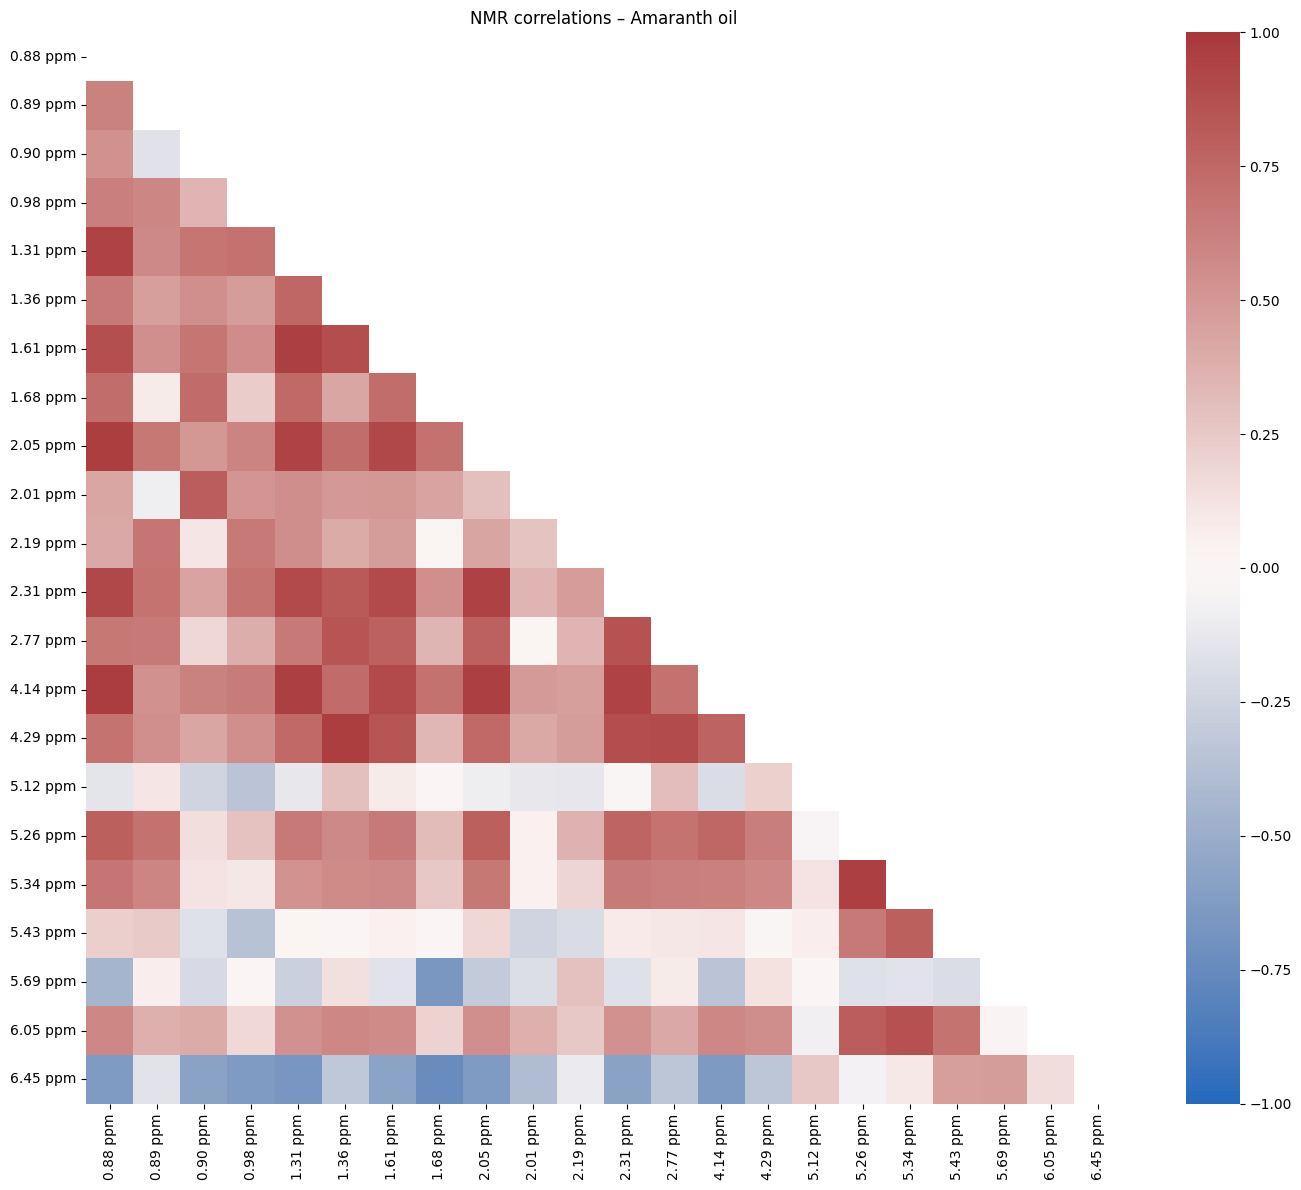

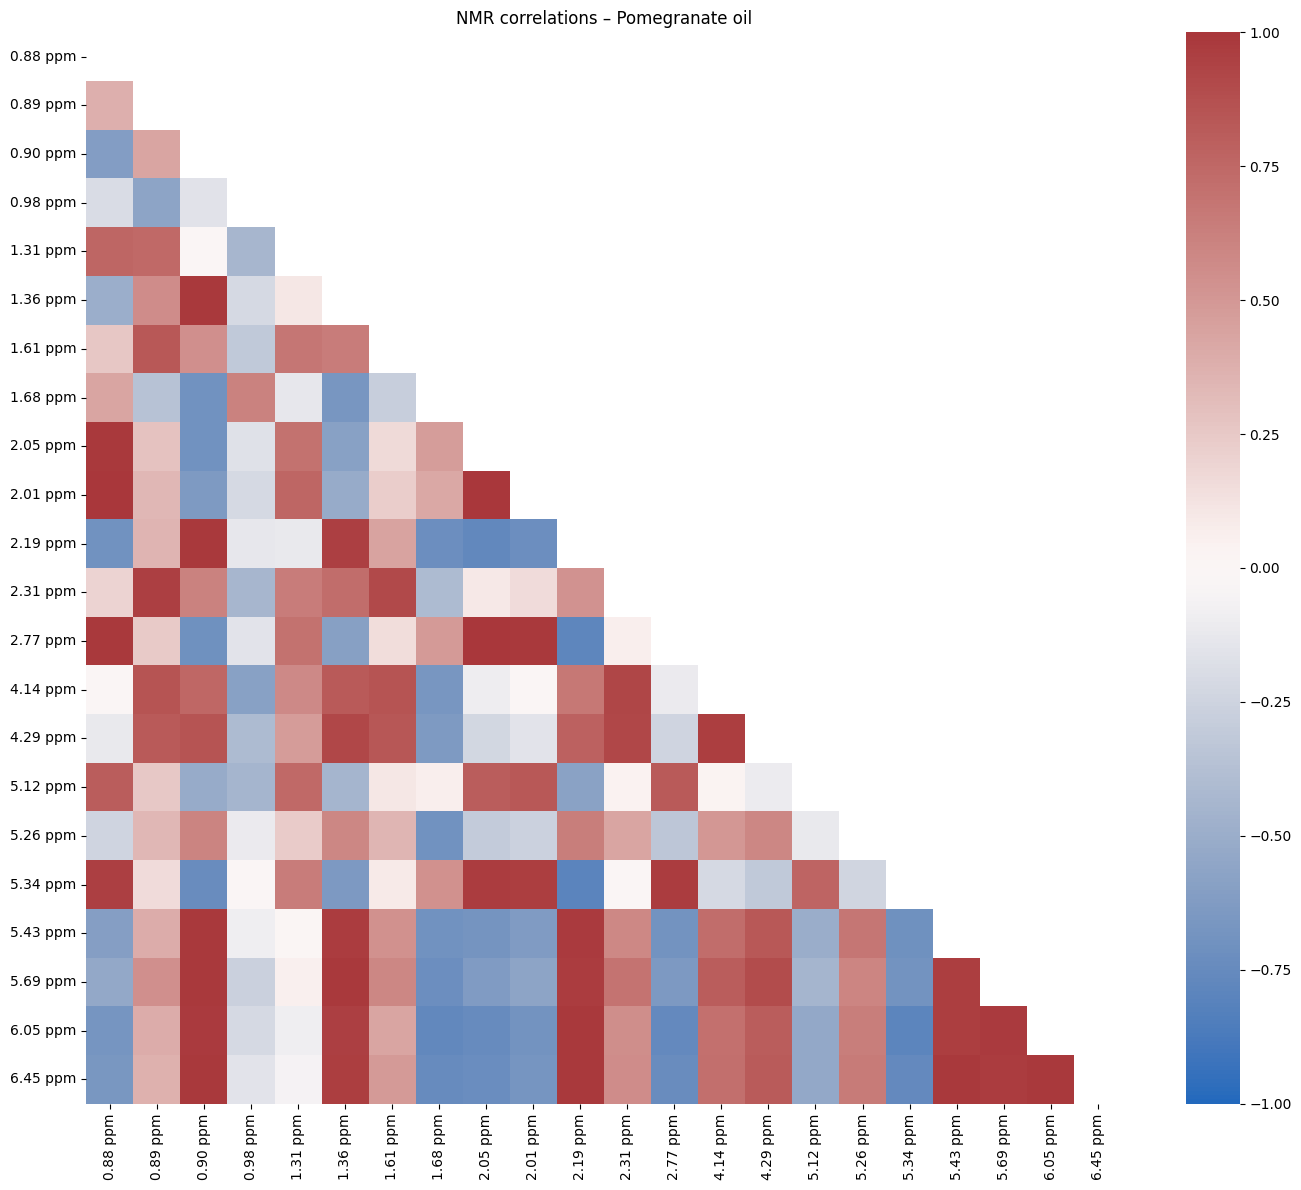

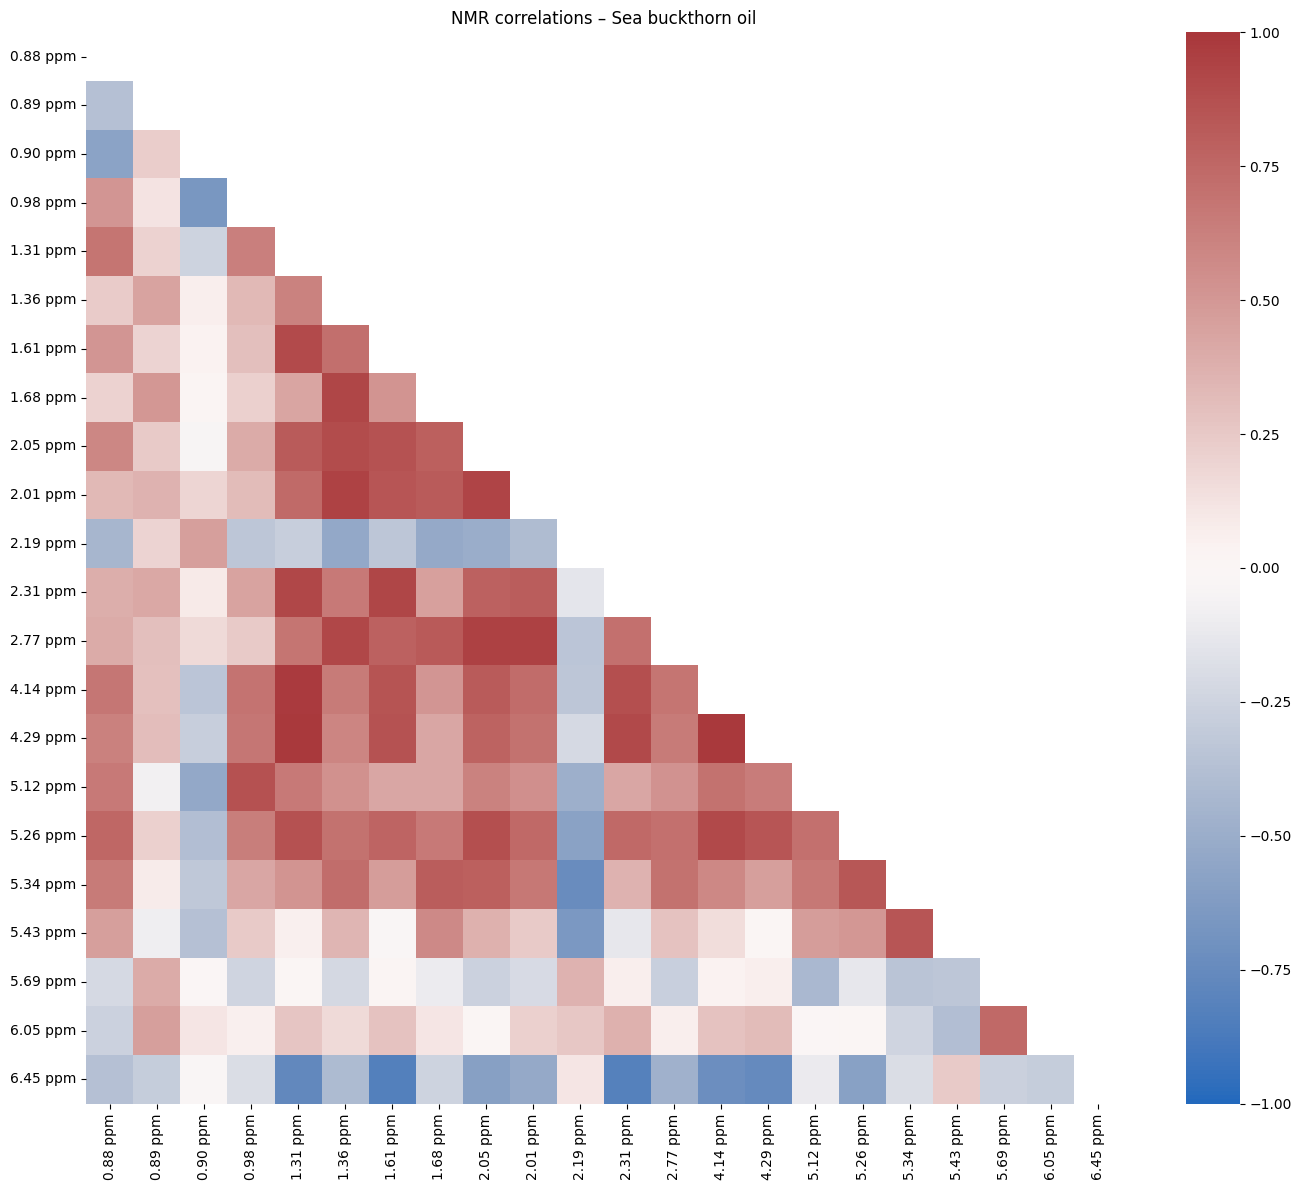

In [13]:
for oil_type, group in data.groupby("Oil type"):
    correlation_matrix = group[nmr_columns].corr()

    plt.figure(figsize=(14, 12))

    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

    sns.heatmap(correlation_matrix, mask=mask, cmap="vlag", center=0, vmin=-1, vmax=1)

    plt.title(f"NMR correlations – {oil_type}")
    plt.tight_layout()
    plt.show()

In [14]:
strong_correlations_by_oil = []

for oil_type, group in data.groupby("Oil type"):
    
    correlation_matrix = group[nmr_columns].corr()

    # Keep only one value for each variable pair
    upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

    correlation_pairs = (upper_triangle .stack().reset_index())

    correlation_pairs.columns = ["Variable 1", "Variable 2", "correlation"]

    correlation_pairs["absolute correlation"] = (correlation_pairs["correlation"].abs())

    # Select strong correlations
    strong_correlations = correlation_pairs[correlation_pairs["absolute correlation"] >= 0.85].copy()

    strong_correlations.insert(0, "Oil type", oil_type)

    strong_correlations_by_oil.append(strong_correlations)

# Combine results for all oil types
all_strong_correlations_by_oil = (pd.concat(strong_correlations_by_oil, ignore_index=True
                                      ).sort_values(["Oil type","absolute correlation"], 
                                      ascending=[True, False])
                                      .reset_index(drop=True)
                                      .round(4))

display(all_strong_correlations_by_oil.head())

,Oil type,Variable 1,Variable 2,correlation,absolute correlation
0,Amaranth oil,0.88 ppm,4.14 ppm,0.9713,0.9713
1,Amaranth oil,0.88 ppm,2.05 ppm,0.9675,0.9675
2,Amaranth oil,1.36 ppm,4.29 ppm,0.9651,0.9651
3,Amaranth oil,5.26 ppm,5.34 ppm,0.9568,0.9568
4,Amaranth oil,1.31 ppm,1.61 ppm,0.9560,0.9560


### 3.7 Pairwise volcano plots

Each volcano plot compares two oil types. The x-axis shows the log2 ratio of group means and the y-axis shows FDR-adjusted statistical evidence. This is an exploratory adaptation of a common omics visualization and should be interpreted together with distribution plots and effect sizes.


In [15]:
def create_volcano_plot(df, group1, group2, fold_change_threshold=1.0, fdr_threshold=0.05):
    results = []

    group1_data = df[df["Oil type"] == group1]

    group2_data = df[df["Oil type"] == group2]

    for column in nmr_columns:
        values1 = group1_data[column].dropna()
        values2 = group2_data[column].dropna()

        if len(values1) < 2 or len(values2) < 2:
            continue

        statistic, p_value = ttest_ind(values1, values2, equal_var=False, nan_policy="omit")

        mean1 = values1.mean()
        mean2 = values2.mean()

        pseudocount = 1e-9

        log2_fold_change = np.log2((mean2 + pseudocount) / (mean1 + pseudocount))

        results.append({"NMR variable": column, 
                        "mean group 1": mean1, 
                        "mean group 2": mean2,
                        "log2 fold change": log2_fold_change, 
                        "p-value": p_value})

    volcano_data = pd.DataFrame(results)

    if volcano_data.empty:
        print(f"No valid results for " f"{group1} vs {group2}")
        return volcano_data

    volcano_data["FDR"] = multipletests(volcano_data["p-value"], method="fdr_bh")[1]

    volcano_data["-log10(FDR)"] = -np.log10(volcano_data["FDR"].clip(lower=1e-300))

    volcano_data["significant"] = ((volcano_data["FDR"] < fdr_threshold) & (volcano_data["log2 fold change"]
                                                                            .abs() >= fold_change_threshold))

    plt.figure(figsize=(7, 6))

    sns.scatterplot(data=volcano_data, x="log2 fold change",y="-log10(FDR)",hue="significant",
                                                                            s=75, alpha=0.85)

    plt.axhline(-np.log10(fdr_threshold), linestyle="--")

    plt.axvline(fold_change_threshold, linestyle="--")

    plt.axvline(-fold_change_threshold, linestyle="--")

    labels_to_show = (volcano_data .sort_values(["significant", "FDR"], ascending=[False, True]) .head(5))

    for _, row in labels_to_show.iterrows():
        plt.text(row["log2 fold change"], row["-log10(FDR)"], row["NMR variable"], fontsize=8)

    plt.xlabel(f"log2 mean ratio " f"({group2} / {group1})")

    plt.ylabel("-log10(FDR)")

    plt.title(f"Volcano plot: " f"{group1} vs {group2}")

    safe_name = (f"{group1}_vs_{group2}" .lower() .replace(" ", "_") .replace("/", "_") .replace("\\", "_"))

    output_path = (FIGURES_DIR / f"volcano_{safe_name}.png")

    plt.tight_layout()

    plt.savefig(output_path, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close()

    print(f"Saved: {output_path}")

    return (volcano_data
            .sort_values(["significant", "FDR"],
            ascending=[False, True])
            .reset_index(drop=True))

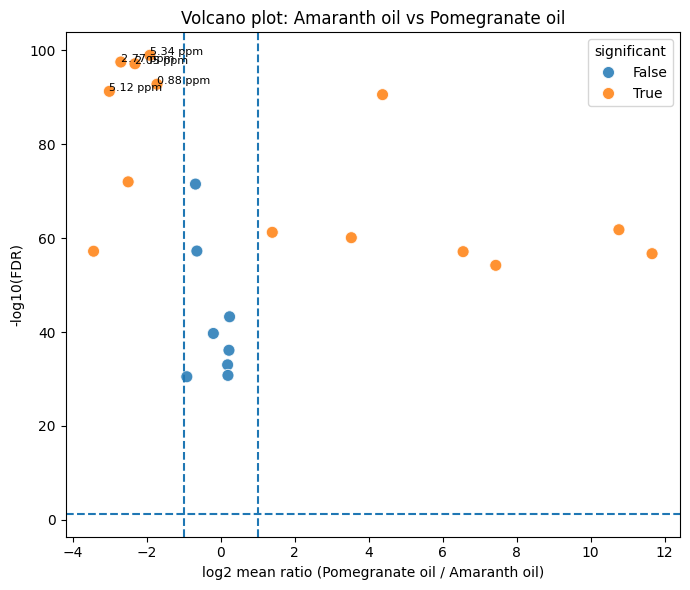

Saved: diagrams/03/volcano_amaranth_oil_vs_pomegranate_oil.png

Top results: Amaranth oil vs Pomegranate oil


,NMR variable,mean group 1,mean group 2,log2 fold change,p-value,FDR,-log10(FDR),significant
0,5.34 ppm,685.542200,182.133878,-1.912246,5.133315e-101,1.129329e-99,98.947179,True
1,2.77 ppm,286.628200,44.231020,-2.696050,2.791647e-99,3.070812e-98,97.512747,True
2,2.05 ppm,539.922200,108.634082,-2.313275,9.934050e-99,7.284970e-98,97.137572,True
3,0.88 ppm,125.926867,38.257143,-1.718785,3.021541e-94,1.661848e-93,92.779409,True
4,5.12 ppm,6.191200,0.770680,-3.006015,1.232696e-92,5.423862e-92,91.265691,True
5,5.43 ppm,23.009800,478.158163,4.377168,7.507799e-92,2.752859e-91,90.560216,True
6,2.01 ppm,542.835200,96.094286,-2.497992,3.260157e-73,1.024621e-72,71.989437,True
7,6.45 ppm,0.272200,474.075102,10.766233,6.588707e-63,1.610573e-62,61.793020,True
8,1.36 ppm,560.251200,1475.692245,1.397246,2.609731e-62,5.741407e-62,61.240982,True
9,0.90 ppm,13.549000,156.878367,3.533388,4.005594e-61,8.011187e-61,60.096303,True


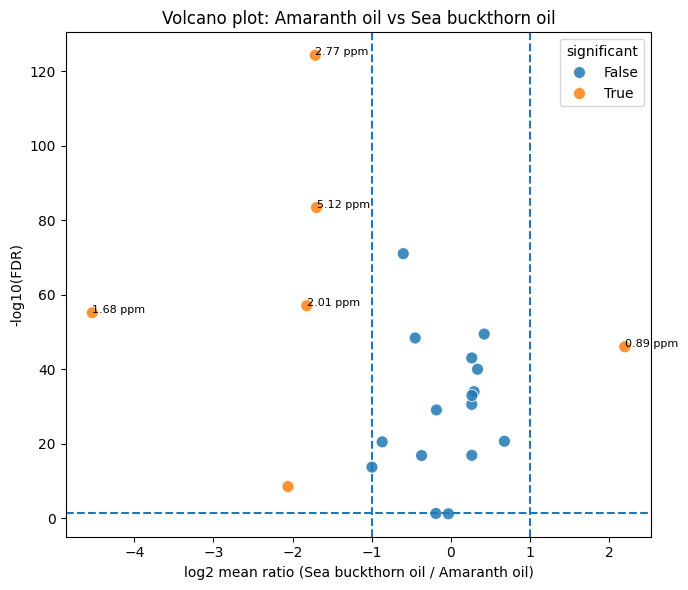

Saved: diagrams/03/volcano_amaranth_oil_vs_sea_buckthorn_oil.png

Top results: Amaranth oil vs Sea buckthorn oil


,NMR variable,mean group 1,mean group 2,log2 fold change,p-value,FDR,-log10(FDR),significant
0,2.77 ppm,286.6282,87.367600,-1.714010,2.202059e-126,4.844530e-125,124.314748,True
1,5.12 ppm,6.1912,1.908333,-1.697906,3.484260e-85,3.832686e-84,83.416497,True
2,2.01 ppm,542.8352,153.617400,-1.821173,1.658048e-58,9.119264e-58,57.040040,True
3,1.68 ppm,80.3422,3.477200,-4.530160,1.598940e-56,7.035334e-56,55.152715,True
4,0.89 ppm,14.5514,66.624200,2.194888,3.603378e-47,9.909289e-47,46.003958,True
5,5.43 ppm,23.0098,5.525400,-2.058098,3.122574e-09,3.434831e-09,8.464095,True
6,1.36 ppm,560.2512,368.922200,-0.602757,1.297515e-72,9.515110e-72,71.021586,False
7,2.05 ppm,539.9222,722.206600,0.419660,1.039271e-50,3.810660e-50,49.419000,False
8,5.34 ppm,685.5422,501.108000,-0.452124,1.390543e-49,4.370277e-49,48.359491,False
9,2.31 ppm,601.6028,721.668600,0.262525,4.010529e-44,9.803515e-44,43.008618,False


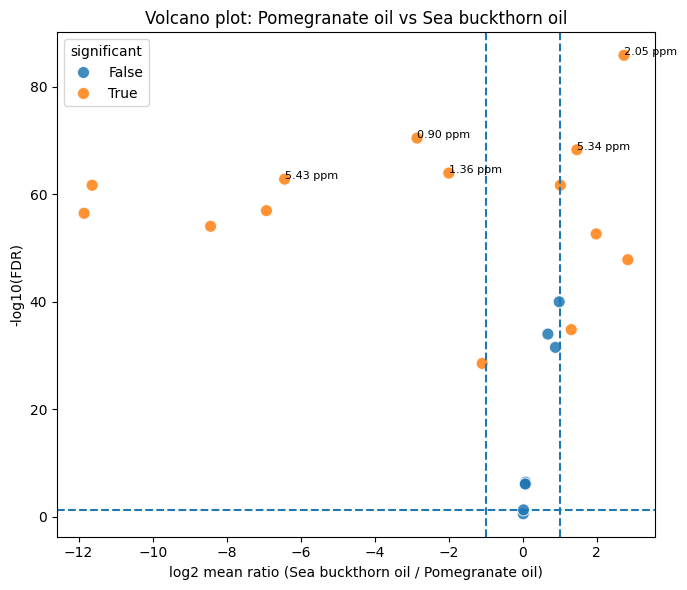

Saved: diagrams/03/volcano_pomegranate_oil_vs_sea_buckthorn_oil.png

Top results: Pomegranate oil vs Sea buckthorn oil


,NMR variable,mean group 1,mean group 2,log2 fold change,p-value,FDR,-log10(FDR),significant
0,2.05 ppm,108.634082,722.206600,2.732935,6.217331e-88,1.367813e-86,85.863973,True
1,0.90 ppm,156.878367,21.632467,-2.858376,3.175372e-72,3.492909e-71,70.456813,True
2,5.34 ppm,182.133878,501.108000,1.460122,6.959759e-70,5.103824e-69,68.292104,True
3,1.36 ppm,1475.692245,368.922200,-2.000003,2.025280e-65,1.113904e-64,63.953152,True
4,5.43 ppm,478.158163,5.525400,-6.435265,3.459840e-64,1.522330e-63,62.817491,True
5,1.31 ppm,3316.696531,6697.178400,1.013806,6.427836e-63,2.046092e-62,61.689075,True
6,6.45 ppm,474.075102,0.149000,-11.635588,6.510294e-63,2.046092e-62,61.689075,True
7,2.19 ppm,1020.381020,8.386200,-6.926875,3.997081e-58,1.099197e-57,56.958924,True
8,6.05 ppm,491.905714,0.133000,-11.852740,1.370929e-57,3.351161e-57,56.474805,True
9,5.69 ppm,24.719388,0.071400,-8.435503,4.047342e-55,8.904153e-55,54.050407,True


In [16]:
volcano_results = {}

oil_types = sorted(data["Oil type"].dropna().unique())

for group1, group2 in combinations(oil_types, 2):
    comparison_name = (f"{group1} vs {group2}")

    volcano_results[comparison_name] = create_volcano_plot(data, group1, group2)

    print(f"\nTop results: " f"{comparison_name}")

    display(volcano_results[comparison_name].head(10))

**Interpretation**: 
- Signals located high and far from zero represent the strongest candidate discriminatory markers. 
- The 5.12 and 2.77 ppm signals were particularly important in comparisons involving amaranth oil, while signals near 0.90, 1.36, 2.05 and 5.34-5.43 ppm contributed to the differentiation of pomegranate and sea buckthorn oils. 
- Several signals had very low FDR values but remained within the chenge of fold thresholds, indicating statistically detectable but relatively small differences. 
- The direction of the fold change should be interpreted according to the order used in its calculation. 
- These signals should be treated as candidate markers and further evaluated using effect sizes, pairwise validation and classification performance.

### Exploratory-analysis interpretation

- Boxplots and violin plots reveal whether oil types differ in central tendency, variability and distribution shape.
- Histograms and density curves show overlap, skewness and possible multimodality.
- The scatter plot assesses whether two signals jointly separate oil groups.
- Strong correlations indicate redundant NMR information and support the later use of PCA.
- Volcano plots identify pairwise differences that combine effect size with FDR-adjusted statistical evidence.
- Results involving variables with substantial imputation should be interpreted cautiously.


## 4. Standardize NMR variables

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=nmr_columns, index=data.index)

X_scaled_df.head()

,0.88 ppm,0.89 ppm,0.90 ppm,0.98 ppm,1.31 ppm,1.36 ppm,1.61 ppm,1.68 ppm,2.05 ppm,2.01 ppm,2.19 ppm,2.31 ppm,2.77 ppm,4.14 ppm,4.29 ppm,5.12 ppm,5.26 ppm,5.34 ppm,5.43 ppm,5.69 ppm,6.05 ppm,6.45 ppm
0,0.406458,-0.559464,-0.776676,0.742449,0.133508,-0.479783,1.213808,1.218490,0.303222,1.308919,-0.692608,-1.239718,1.416480,-1.140040,-1.102120,1.501109,-1.086752,1.112416,-0.693677,-0.691467,-0.697573,-0.697957
1,0.256113,-0.676408,-0.757509,0.401349,-0.112692,-0.523823,0.512653,1.217366,0.131458,1.470538,-0.696512,-1.732174,1.309419,-1.634462,-1.427313,1.364977,-1.573099,0.951873,-0.695003,-0.692328,-0.697616,-0.697957
2,0.310784,-0.590419,-0.768613,0.641669,0.013167,-0.478417,1.058316,1.175209,0.248166,1.234769,-0.695127,-1.445321,1.404007,-1.557673,-1.234171,1.522380,-1.382034,1.036088,-0.684991,-0.686301,-0.697616,-0.698046
3,0.366883,-0.627490,-0.755379,0.506004,0.096970,-0.544146,1.057775,1.538037,0.284210,1.234018,-0.695274,-1.563346,1.338806,-1.365948,-1.547145,1.267132,-1.415687,0.958278,-0.695323,-0.694911,-0.697746,-0.698360
4,0.538239,-0.589655,-0.735147,0.905246,0.385922,-0.419682,2.105088,1.628534,0.432346,1.702101,-0.694119,-0.977497,1.428481,-0.712004,-0.952212,1.360723,-1.053099,1.166472,-0.673058,-0.694050,-0.697271,-0.698495


### Mean standardized NMR profiles by oil type

The heatmap summarizes the average standardized intensity of every NMR variable within each oil group.

- Positive values indicate signals above the overall dataset mean.
- Negative values indicate signals below the overall dataset mean.
- Similar vertical patterns suggest similar oil profiles.
- Strong contrasts help explain the later PCA separation.


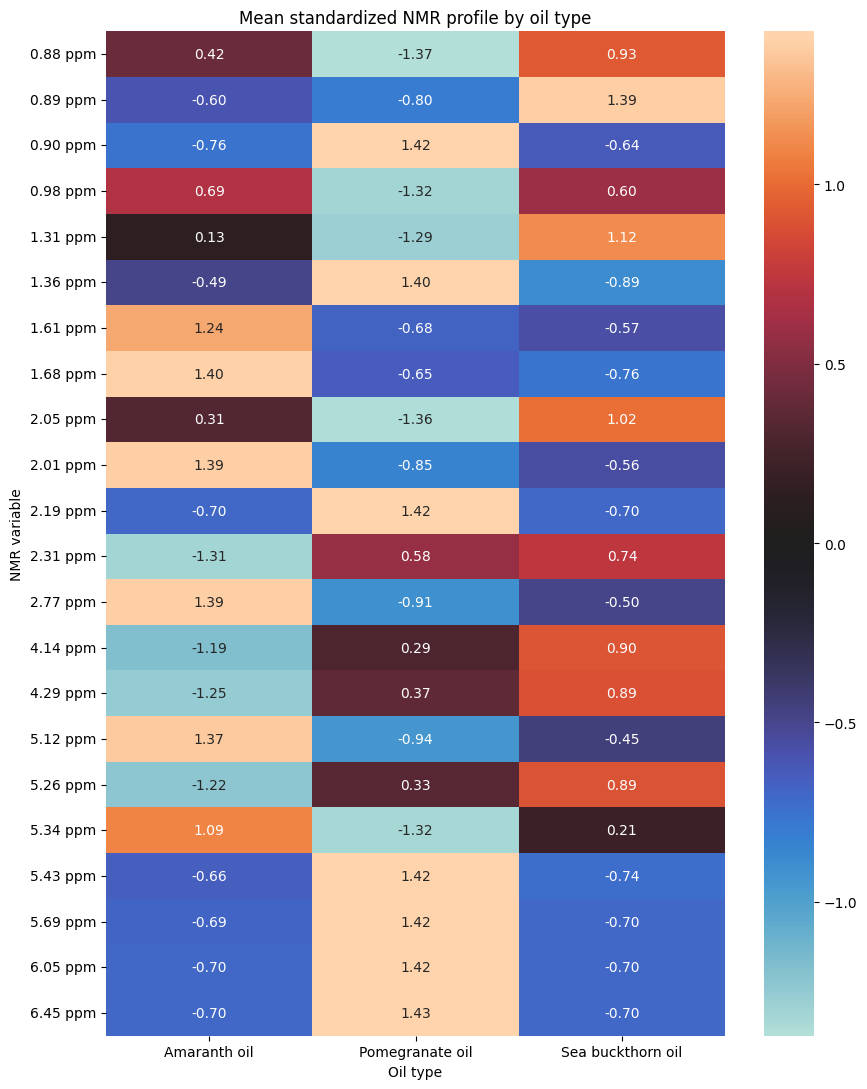

Oil type,Amaranth oil,Pomegranate oil,Sea buckthorn oil
0.88 ppm,0.416,-1.373,0.929
0.89 ppm,-0.602,-0.802,1.388
0.90 ppm,-0.758,1.422,-0.635
0.98 ppm,0.692,-1.316,0.597
1.31 ppm,0.135,-1.285,1.125
1.36 ppm,-0.490,1.404,-0.886
1.61 ppm,1.238,-0.680,-0.572
1.68 ppm,1.399,-0.650,-0.762
2.05 ppm,0.313,-1.360,1.020
2.01 ppm,1.390,-0.847,-0.559


In [18]:
scaled_with_labels = X_scaled_df.copy()
scaled_with_labels["Oil type"] = y

mean_standardized_profiles = (scaled_with_labels .groupby("Oil type") .mean() .T)

plt.figure(figsize=(9, 11))

sns.heatmap(mean_standardized_profiles, center=0, annot=True, fmt=".2f")

plt.xlabel("Oil type")
plt.ylabel("NMR variable")
plt.title("Mean standardized NMR profile by oil type")
plt.tight_layout()
plt.show()

display(mean_standardized_profiles.round(3))


In [20]:
profile_summary = []

for oil_type in mean_standardized_profiles.columns:
    highest_signals = (mean_standardized_profiles[oil_type] .sort_values(ascending=False) .head(5))

    lowest_signals = (mean_standardized_profiles[oil_type] .sort_values() .head(5))

    profile_summary.append({"Oil type": oil_type, "Highest standardized signals": 
                            ",".join(highest_signals.index), "Lowest standardized signals": 
                            ", ".join(lowest_signals.index)})

profile_summary = pd.DataFrame(profile_summary)

display(profile_summary)


,Oil type,Highest standardized signals,Lowest standardized signals
0,Amaranth oil,"1.68 ppm,2.01 ppm,2.77 ppm,5.12 ppm,1.61 ppm","2.31 ppm, 4.29 ppm, 5.26 ppm, 4.14 ppm, 0.90 ppm"
1,Pomegranate oil,"6.45 ppm,2.19 ppm,6.05 ppm,5.43 ppm,5.69 ppm","0.88 ppm, 2.05 ppm, 5.34 ppm, 0.98 ppm, 1.31 ppm"
2,Sea buckthorn oil,"0.89 ppm,1.31 ppm,2.05 ppm,0.88 ppm,4.14 ppm","1.36 ppm, 1.68 ppm, 5.43 ppm, 2.19 ppm, 5.69 ppm"


**Note**
- The heatmap revealed distinct standardized NMR profiles for the three oil types.
- Amaranth oil showed high relative intensities at 1.61, 1.68, 2.01, 2.77 and 5.12 ppm.
- Pomegranate oil was characterized by high signals at 0.90, 1.36, 2.19 and in the 5.43–6.45 ppm region.
- Sea buckthorn oil showed particularly high relative intensities at 0.89, 1.31, 2.05, 4.14, 4.29 and 5.26 ppm.
- The contrasting profiles indicate that different combinations of NMR signals characterize each oil type and help explain their separation in PCA.
- The heatmap represents group means and should therefore be interpreted together with distribution plots and statistical tests.

## 5. Principal component analysis (PCA)

The main PCA model retains five components for downstream interpretation. A full PCA model is also fitted below to assess how many components are supported by explained variance and the Kaiser criterion.


#### PCA interpretation guide

Use the PCA outputs together:

- The scree plot shows how rapidly information is concentrated in the first components.
- Cumulative variance indicates how many components are required to retain most of the NMR information.
- The Kaiser criterion provides an additional component-selection check.
- The mean standardized profile heatmap shows which oil groups have high or low values for each signal.
- The score plot shows sample separation.
- The biplot connects that separation to the most influential NMR variables.
- PC1-PC3 is displayed only when it improves the descriptive group-separation score.


In [21]:
pca = PCA(n_components=5)
pca_result = pca.fit_transform(X_scaled)

pca_columns = ["PC1", "PC2", "PC3", "PC4", "PC5"]

pca_df = pd.DataFrame(pca_result, columns=pca_columns, index=data.index)

pca_df = pd.concat([pca_df, y.rename("Oil type")], axis=1)

pca_df.head()

,PC1,PC2,PC3,PC4,PC5,Oil type
0,-3.799725,-2.286082,0.214042,0.062968,-0.076480,Amaranth oil
1,-3.658177,-2.879580,-0.832601,-0.156297,-0.137305,Amaranth oil
2,-3.781487,-2.635358,-0.254208,-0.017315,-0.001534,Amaranth oil
3,-3.818980,-2.722866,-0.302373,-0.137593,-0.036580,Amaranth oil
4,-4.096540,-2.258988,1.257423,0.037542,0.263496,Amaranth oil


### Explained variance

In [22]:
explained_variance = pca.explained_variance_ratio_ * 100

explained_variance_df = pd.DataFrame({"principal_component": pca_columns,
    "explained_variance_percent": explained_variance, 
    "cumulative_variance_percent": np.cumsum(explained_variance)})

explained_variance_df

,principal_component,explained_variance_percent,cumulative_variance_percent
0,PC1,64.705258,64.705258
1,PC2,30.750788,95.456046
2,PC3,3.079085,98.535132
3,PC4,0.647048,99.182180
4,PC5,0.355625,99.537805


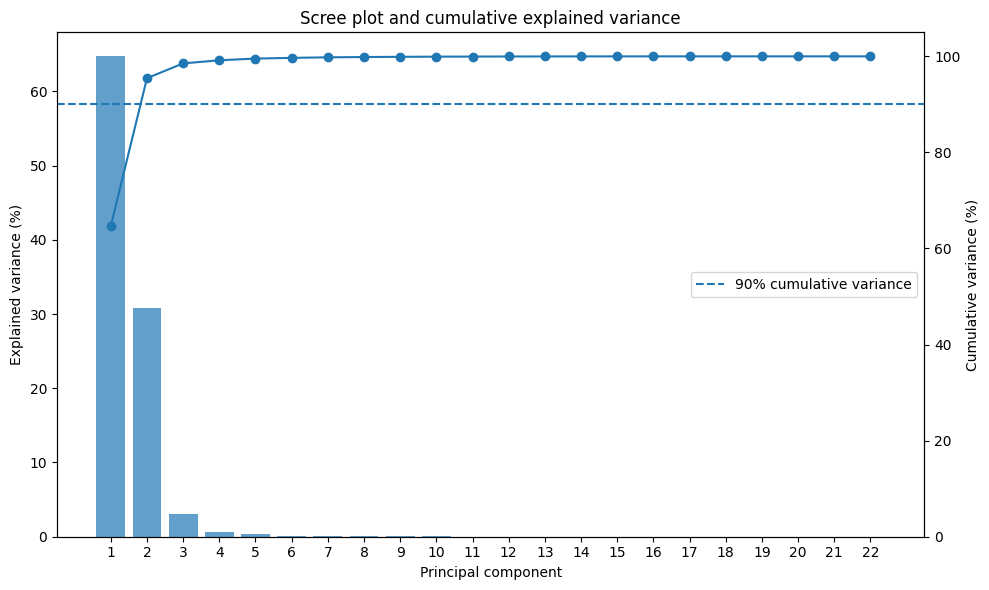

Components required for at least 80% variance: 2
Components required for at least 90% variance: 2
Components required for at least 95% variance: 2


In [23]:
# Fit PCA with all available components for component-selection diagnostics.
pca_full = PCA()
pca_full.fit(X_scaled)

full_explained_variance = (pca_full.explained_variance_ratio_ * 100)

full_cumulative_variance = np.cumsum(full_explained_variance)

component_numbers = np.arange(1, len(full_explained_variance) + 1)

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(component_numbers, full_explained_variance, alpha=0.7)

ax1.set_xlabel("Principal component")
ax1.set_ylabel("Explained variance (%)")
ax1.set_xticks(component_numbers)

ax2 = ax1.twinx()

ax2.plot(component_numbers, full_cumulative_variance, marker="o")

ax2.axhline(90, linestyle="--", label="90% cumulative variance")

ax2.set_ylabel("Cumulative variance (%)")
ax2.set_ylim(0, 105)
ax2.legend(loc="center right")

plt.title("Scree plot and cumulative explained variance")
plt.tight_layout()
plt.show()

components_for_80 = np.argmax(full_cumulative_variance >= 80) + 1

components_for_90 = np.argmax(full_cumulative_variance >= 90) + 1

components_for_95 = np.argmax(full_cumulative_variance >= 95) + 1

print(f"Components required for at least 80% variance: {components_for_80}")
print(f"Components required for at least 90% variance: {components_for_90}")
print(f"Components required for at least 95% variance: {components_for_95}")


### Kaiser criterion

Because the NMR variables were standardized, a component with an eigenvalue above `1` explains more variance than one original standardized variable. The Kaiser criterion is used here as a supporting diagnostic.

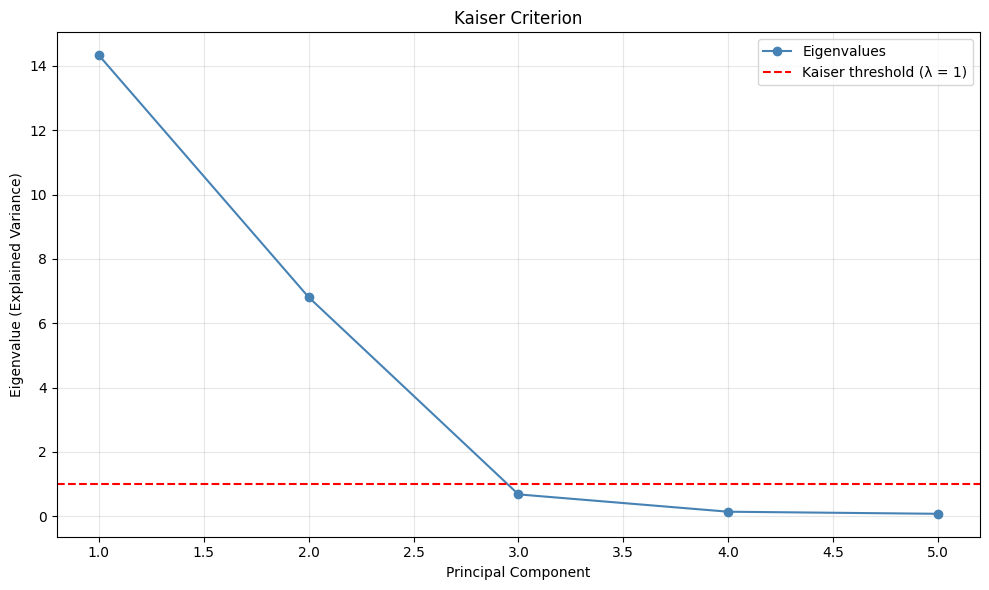

In [24]:
eigenvalues = pca.explained_variance_
kaiser_threshold = 1.0

plt.figure(figsize=(10,6))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, 'o-', color='steelblue', label='Eigenvalues')
plt.axhline(y=kaiser_threshold, color='red', linestyle='--', label='Kaiser threshold (λ = 1)')

plt.title('Kaiser Criterion')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue (Explained Variance)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Note**
- PC1 and PC2 contain the vast majority of the information in the NMR data.
- There is a sharp drop in explained variance after PC2.
- Two components are sufficient to retain over 90% likely around 95-96% of the total variance.
- Subsequent components make a marginal contribution.
- The PC1-PC2 plot thus serves as a good two-dimensional summary of the dataset.

### PCA score plot

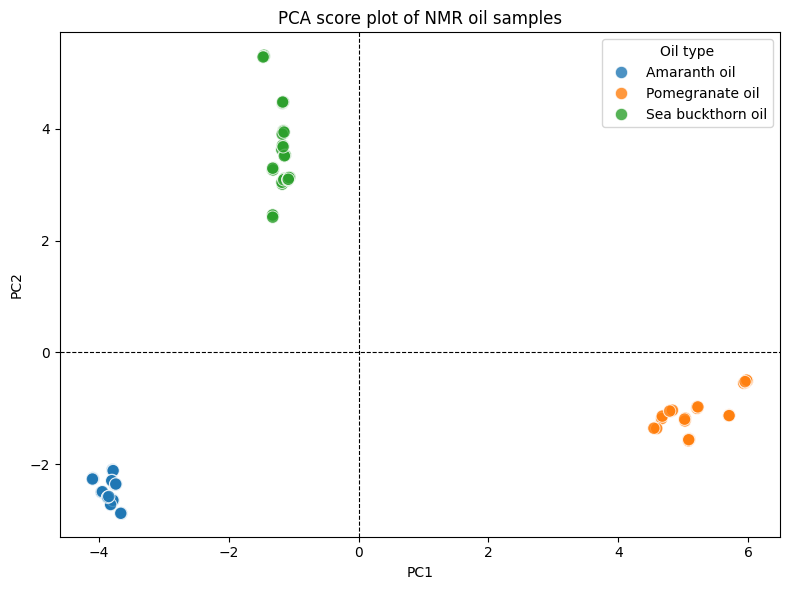

In [25]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Oil type", s=80, alpha=0.8)
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("PCA score plot of NMR oil samples")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_score_plot.png", dpi=300, bbox_inches="tight")
plt.show()

- PC1 primarily separated Pomegranate oil from Amaranth and Sea buckthorn oils, whereas PC2 separated Sea buckthorn oil from the other groups. 
- The absence of cluster overlap indicates distinct multivariate NMR profiles. 
- Samples within each oil type were relatively tightly grouped, although Sea buckthorn oil showed somewhat greater variation within group  along PC2.

### Does PC3 add useful class separation?

The known oil labels are used only for a descriptive comparison of separation in the `PC1-PC2` and `PC1-PC3` planes. The silhouette score is not used here as predictive-model validation.

In [26]:
oil_type_codes = pd.factorize(pca_df["Oil type"])[0]

pc12_separation = silhouette_score(pca_df[["PC1", "PC2"]], oil_type_codes)

pc13_separation = silhouette_score(pca_df[["PC1", "PC3"]], oil_type_codes)

print(f"Label-based silhouette score for PC1-PC2: " f"{pc12_separation:.3f}")

print(f"Label-based silhouette score for PC1-PC3: " f"{pc13_separation:.3f}")

if pc13_separation > pc12_separation:
    print("PC3 improves the two-dimensional separation, " "so the PC1-PC3 plot is displayed.")

    plt.figure(figsize=(8, 6))

    sns.scatterplot(data=pca_df, x="PC1", y="PC3", hue="Oil type", s=80, alpha=0.8)

    plt.axhline(0, linewidth=0.8, linestyle="--")

    plt.axvline(0, linewidth=0.8, linestyle="--")

    plt.xlabel(f"PC1 ({explained_variance[0]:.2f}%)")

    plt.ylabel(f"PC3 ({explained_variance[2]:.2f}%)")

    plt.title("PCA score plot: PC1 versus PC3")
    plt.tight_layout()
    plt.show()

else:
    print("PC3 does not improve separation compared with PC1-PC2. " "The additional score plot is therefore omitted.")


Label-based silhouette score for PC1-PC2: 0.916
Label-based silhouette score for PC1-PC3: 0.737
PC3 does not improve separation compared with PC1-PC2. The additional score plot is therefore omitted.


### PCA loadings

In [27]:
correlation_loadings = pd.DataFrame(pca.components_.T * np.sqrt(pca.explained_variance_), 
                                    index=nmr_columns, columns=[f"PC{i+1}" for i in range(pca.n_components_)])

correlation_loadings.head()

,PC1,PC2,PC3,PC4,PC5
0.88 ppm,-0.864465,0.493526,0.038809,-0.006643,-0.053435
0.89 ppm,-0.300677,0.941634,-0.111355,-0.039866,0.047602
0.90 ppm,0.973307,-0.236623,0.046621,0.017141,0.014669
0.98 ppm,-0.907092,0.243091,0.016058,0.339574,0.095807
1.31 ppm,-0.746231,0.666667,0.054508,-0.027902,0.013684


In [28]:
top_loadings_pc1 = (correlation_loadings["PC1"] .abs() .sort_values(ascending=False) .head(10) .index)
correlation_loadings.loc[top_loadings_pc1, ["PC1", "PC2"]]

,PC1,PC2
5.34 ppm,-0.993313,-0.065196
0.90 ppm,0.973307,-0.236623
6.05 ppm,0.960384,-0.282863
6.45 ppm,0.960176,-0.284314
2.19 ppm,0.959645,-0.285149
5.69 ppm,0.959536,-0.283928
5.43 ppm,0.949260,-0.313695
0.98 ppm,-0.907092,0.243091
1.36 ppm,0.899774,-0.429171
0.88 ppm,-0.864465,0.493526


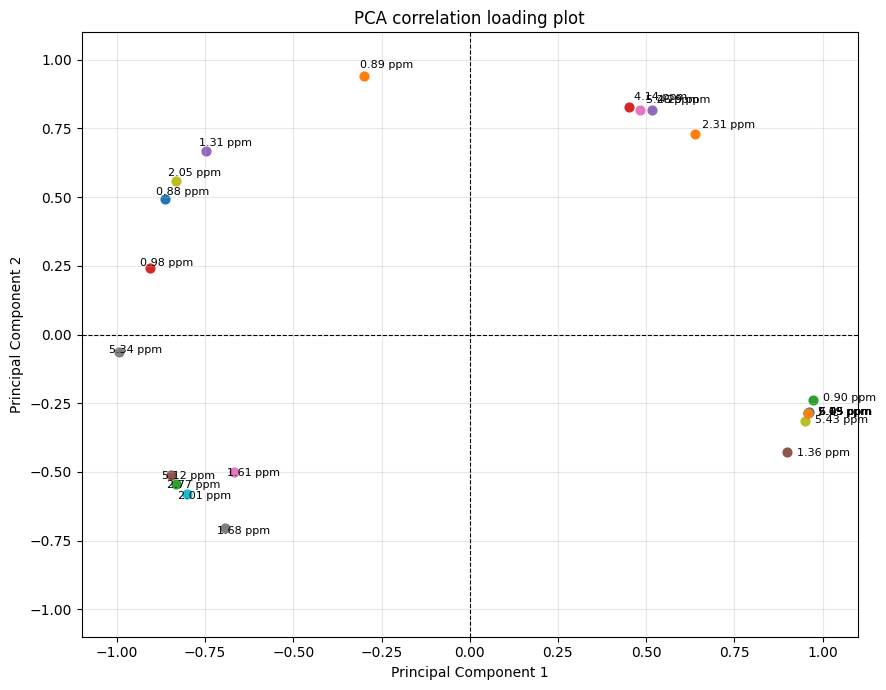

In [29]:
plt.figure(figsize=(9, 7))

for variable in correlation_loadings.index:
    plt.scatter(correlation_loadings.loc[variable, "PC1"], correlation_loadings.loc[variable, "PC2"], s=40)

    plt.text(correlation_loadings.loc[variable, "PC1"] * 1.03,
             correlation_loadings.loc[variable, "PC2"] * 1.03, variable, fontsize=8)

plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA correlation loading plot")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### PCA biplot

The biplot combines sample scores with the ten variables having the largest combined contribution to PC1 and PC2.

- Samples projected in the direction of an arrow tend to have higher values for that NMR variable.
- Longer arrows indicate a stronger contribution within the PC1-PC2 plane.
- Arrows pointing in similar directions indicate positively related variables.
- Opposing arrows indicate negative relationships.


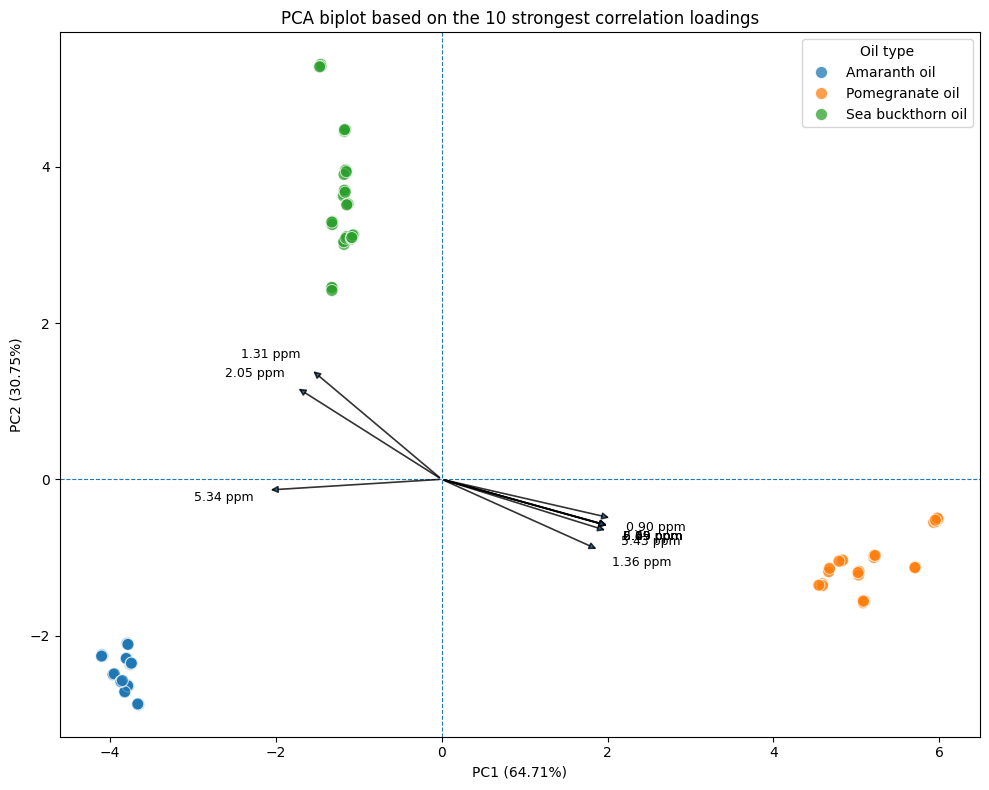

In [30]:
# Correlation loadings
correlation_loadings = pd.DataFrame(pca.components_.T * np.sqrt(pca.explained_variance_),
                            index=nmr_columns, columns=pca_columns)

# Combined association of each NMR variable with PC1 and PC2
correlation_loading_importance = np.sqrt(correlation_loadings["PC1"] ** 2 + correlation_loadings["PC2"] ** 2)

# Select the 10 variables most strongly represented by PC1 and PC2
top_biplot_features = (correlation_loading_importance .sort_values(ascending=False).head(10).index)

# Correlation loadings used in the biplot
biplot_correlation_loadings = correlation_loadings.loc[top_biplot_features, ["PC1", "PC2"]].copy()

# Limits of PCA scores
pc1_limit = np.abs(pca_df["PC1"]).max()
pc2_limit = np.abs(pca_df["PC2"]).max()

# Limits of correlation loadings
loading_pc1_limit = np.abs(biplot_correlation_loadings["PC1"]).max()

loading_pc2_limit = np.abs(biplot_correlation_loadings["PC2"]).max()

# Scale correlation loadings so that arrows are visible with PCA scores
arrow_scale = 0.35 * min(pc1_limit / loading_pc1_limit, pc2_limit / loading_pc2_limit)

fig, ax = plt.subplots(figsize=(10, 8))

# PCA scores of samples
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Oil type", s=75, alpha=0.75, ax=ax)

# Arrows based only on correlation loadings
for variable in top_biplot_features:

    arrow_x = (biplot_correlation_loadings.loc[variable, "PC1"] * arrow_scale)

    arrow_y = (biplot_correlation_loadings.loc[variable, "PC2"] * arrow_scale)

    ax.annotate("", xy=(arrow_x, arrow_y), xytext=(0, 0), 
                arrowprops={"arrowstyle": "-|>", "linewidth": 1.2, "alpha": 0.8})

    ax.text(arrow_x * 1.08, arrow_y * 1.08, variable, 
            fontsize=9, ha="left" if arrow_x >= 0 else "right", va="bottom" if arrow_y >= 0 else "top")

ax.axhline(0, linewidth=0.8, linestyle="--")

ax.axvline(0, linewidth=0.8, linestyle="--")

ax.set_xlabel(f"PC1 ({explained_variance[0]:.2f}%)")

ax.set_ylabel(f"PC2 ({explained_variance[1]:.2f}%)")

ax.set_title("PCA biplot based on the 10 strongest correlation loadings")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_biplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [31]:
# Correlation loadings used in the biplot
biplot_correlation_loadings = correlation_loadings.loc[top_biplot_features, ["PC1", "PC2"]].copy()


# Create a table for the 10 strongest correlation loadings
biplot_loadings_table = (biplot_correlation_loadings
                         .assign(**{"Absolute PC1 loading":(biplot_correlation_loadings["PC1"].abs()), 
                                    "Absolute PC2 loading": (biplot_correlation_loadings["PC2"].abs()),
    "Combined importance": np.sqrt(biplot_correlation_loadings["PC1"] 
                                   ** 2 + biplot_correlation_loadings["PC2"] ** 2)})
            .reset_index() 
            .rename(columns={"index": "NMR variable", 
                             "PC1": "PC1 correlation loading", 
                             "PC2": "PC2 correlation loading"}) 
            .sort_values("Combined importance", ascending=False) .reset_index(drop=True) .round(4))

display(biplot_loadings_table)

,NMR variable,PC1 correlation loading,PC2 correlation loading,Absolute PC1 loading,Absolute PC2 loading,Combined importance
0,2.05 ppm,-0.8314,0.5589,0.8314,0.5589,1.0018
1,0.90 ppm,0.9733,-0.2366,0.9733,0.2366,1.0017
2,6.45 ppm,0.9602,-0.2843,0.9602,0.2843,1.0014
3,6.05 ppm,0.9604,-0.2829,0.9604,0.2829,1.0012
4,2.19 ppm,0.9596,-0.2851,0.9596,0.2851,1.0011
5,5.69 ppm,0.9595,-0.2839,0.9595,0.2839,1.0007
6,1.31 ppm,-0.7462,0.6667,0.7462,0.6667,1.0007
7,5.43 ppm,0.9493,-0.3137,0.9493,0.3137,0.9997
8,1.36 ppm,0.8998,-0.4292,0.8998,0.4292,0.9969
9,5.34 ppm,-0.9933,-0.0652,0.9933,0.0652,0.9955


**Interpretation**
- PCA shows three separated clusters corresponding to each oil types.
- PC1 mainly separated Pomegranate oil from the other groups, whereas PC2 distinguished Sea buckthorn oil. 
- Amaranth oil was associated with signals such as 1.61, 1.68, 2.01, 2.77 and 5.12 ppm, Sea buckthorn oil with 0.88, 0.89, 0.98, 1.31 and 2.05 ppm, and Pomegranate oil with 0.90, 1.36 and signals in the 5.43-6.45 ppm region.
- PC1 and PC2 explained approximately 95.46% of the total variance, indicating that the two-dimensional representation retained most of the information contained in the standardized NMR dataset.

## 6. Search for the number of K-means clusters

Compared inertia and silhouette score for several values of `k`.

In [32]:
list_inertia = []
list_silhouette = []
list_k = []

max_k = 8

for k in range(2, max_k + 1):
    model = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)

    model.fit(pca_df[["PC1", "PC2"]])

    silhouette_value = silhouette_score(pca_df[["PC1", "PC2"]], model.labels_)

    print("clusters:", k, "inertia:", round(model.inertia_, 3), "silhouette:", round(silhouette_value, 3))

    list_inertia.append(model.inertia_)
    list_silhouette.append(silhouette_value)
    list_k.append(k)

clusters: 2 inertia: 1114.123 silhouette: 0.689
clusters: 3 inertia: 44.039 silhouette: 0.916
clusters: 4 inertia: 29.422 silhouette: 0.817
clusters: 5 inertia: 16.167 silhouette: 0.749
clusters: 6 inertia: 11.646 silhouette: 0.75
clusters: 7 inertia: 9.445 silhouette: 0.616
clusters: 8 inertia: 7.702 silhouette: 0.639


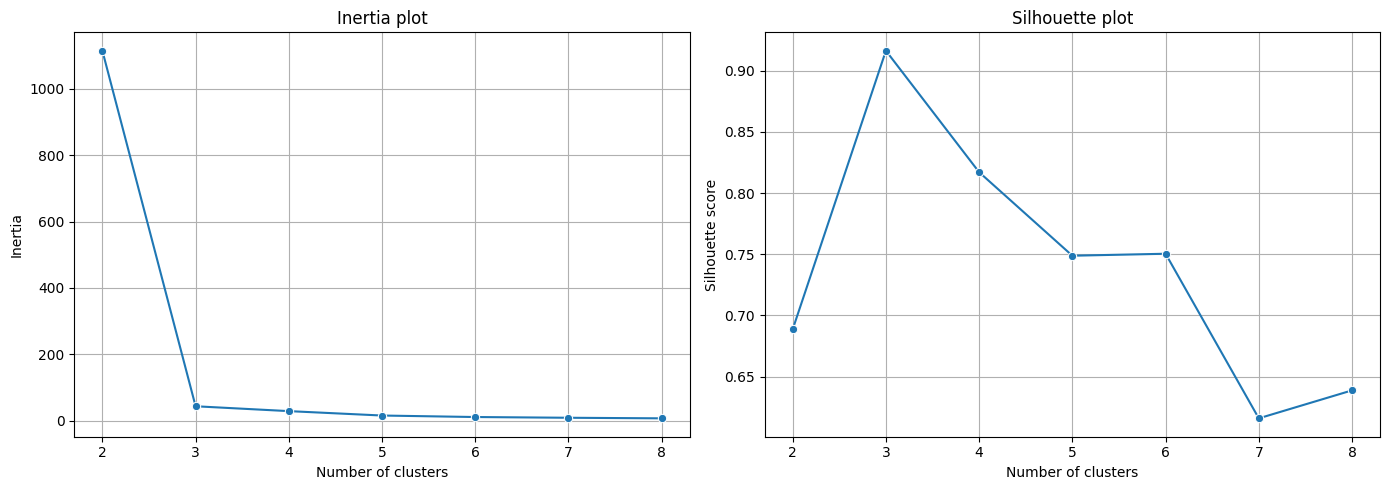

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(x=list_k, y=list_inertia, marker="o", ax=axes[0])
axes[0].set_title("Inertia plot")
axes[0].set_xlabel("Number of clusters")
axes[0].set_ylabel("Inertia")
axes[0].grid(True)

sns.lineplot(x=list_k, y=list_silhouette, marker="o", ax=axes[1])
axes[1].set_title("Silhouette plot")
axes[1].set_xlabel("Number of clusters")
axes[1].set_ylabel("Silhouette score")
axes[1].grid(True)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "kmeans_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

The elbow plot showed a substantial decrease in inertia when the number of clusters increased from 2 to 3, followed by much smaller improvements for additional clusters. The silhouette score reached its maximum at three clusters (0.916), indicating compact and clearly separated groups. Both criteria therefore supported selecting k = 3. This agrees with the presence of three oil types in NMR profiles.

## 7. K-means clustering of the PCA scores

Because the dataset contains three known oil types, the class-based analysis used three clusters.

In [34]:
kmeans_model = KMeans(n_clusters=3, init="k-means++", n_init=10, random_state=42)

cluster_labels = kmeans_model.fit_predict(pca_df[["PC1", "PC2"]])

pca_df["cluster"] = cluster_labels

cluster_silhouette = silhouette_score(pca_df[["PC1", "PC2"]], cluster_labels)

oil_type_numerical, oil_type_names = pd.factorize(pca_df["Oil type"])

ari_score = adjusted_rand_score(oil_type_numerical, cluster_labels)

print(f"Silhouette score: {cluster_silhouette:.3f}")
print(f"Adjusted Rand index: {ari_score:.3f}")

Silhouette score: 0.916
Adjusted Rand index: 1.000


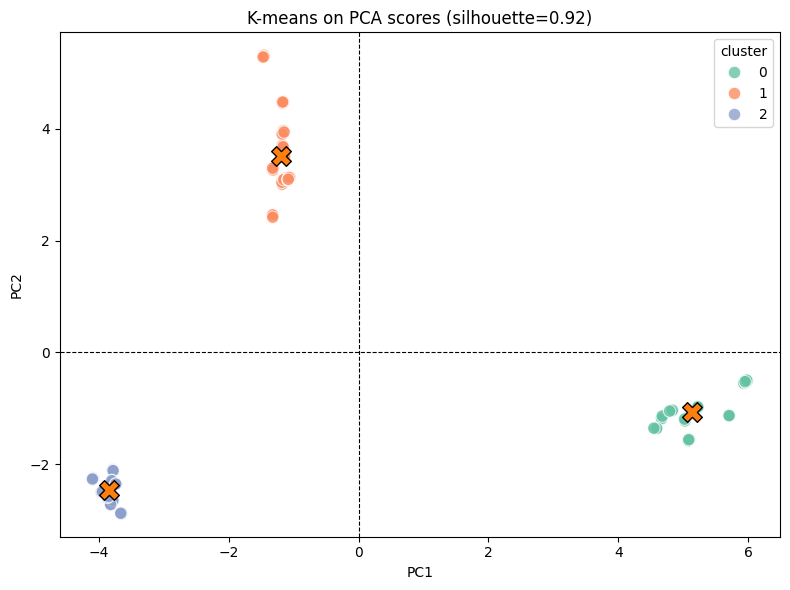

In [35]:
plt.figure(figsize=(8, 6))

sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="cluster", palette="Set2", s=80, alpha=0.8)

centers = kmeans_model.cluster_centers_

plt.scatter(centers[:, 0], centers[:, 1], marker="X", s=200, edgecolor="black", label="Centroids")

plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.title(f"K-means on PCA scores (silhouette={cluster_silhouette:.2f})")
plt.tight_layout()
plt.show()

### Cluster composition

In [36]:
cluster_composition = pd.crosstab(pca_df["cluster"], pca_df["Oil type"], margins=True)

cluster_composition

Oil type,Amaranth oil,Pomegranate oil,Sea buckthorn oil,All
cluster,,,,
0,0,49,0,49
1,0,0,50,50
2,50,0,0,50
All,50,49,50,149


**Interpretation**
- K-means recovered the three oil types without using the "Oil type" column.
- Multidimensional NMR profiles contain a strong signal that distinguishes the groups.
- The differences between the oils are far greater than the variability within each oil.
- The result confirms the separation previously observed on the PCA score plot.
- Three clusters represent the optimal solution according to both the elbow plot and the silhouette score.

## 8. KNN classification with leave-one-manufacturer-out validation

This section asks three related questions:

1. Can a KNN classifier trained on selected manufacturers correctly classify oil samples from a manufacturer that was not used during training?
2. Can oil type be predicted using only a small subset of the most informative NMR signals?
3. Does classification depend on one dominant NMR signal, or is the information distributed across the full spectral profile?

A leave-one-manufacturer-out strategy is used. In every outer fold, all samples from one manufacturer form the test set, while all remaining manufacturers form the training set.

To prevent leakage:

- the raw dataset is used for classification,
- missing-value imputation is fitted only on the training subset,
- scaling is fitted only on the training subset,
- PCA loading-based feature selection is performed only on the training subset,
- KNN hyperparameters are selected only within the training subset,
- the held-out manufacturer is used only for final evaluation.

### 8.1 Load classification data before global imputation

The processed dataset remains appropriate for the exploratory PCA and K-means sections.  
For supervised evaluation, the raw data are loaded again so that imputation can be performed separately inside each training fold.

In [37]:
RAW_DATA_PATH = (PROJECT_DIR / "data" / "raw" / "oils_nmr.csv")

RAW_FALLBACK_PATHS = [Path("../oils_nmr.csv"), Path("../data/raw/oils_nmr.csv")]

if RAW_DATA_PATH.exists():
    classification_data_path = RAW_DATA_PATH
else:
    classification_data_path = next((path for path in RAW_FALLBACK_PATHS if path.exists()), None)

if classification_data_path is None:
    raise FileNotFoundError("Raw data were not found. Place the original dataset at " "data/raw/oils_nmr.csv.")

classification_data = pd.read_csv(classification_data_path)

classification_data.columns = (classification_data.columns .astype(str) .str.strip())

classification_nmr_columns = [column for column in classification_data.columns if "ppm" in column.lower()]

classification_data = classification_data.dropna(subset=["Oil type", "Manufacturer"]).copy()

print(f"Loaded classification data: " f"{classification_data_path}")
print(f"Number of samples: " f"{classification_data.shape[0]}")
print(f"Number of NMR variables: " f"{len(classification_nmr_columns)}")
print(f"Number of manufacturers: " f"{classification_data['Manufacturer'].nunique()}")
print(f"Missing NMR values before fold-wise imputation: " 
      f"{classification_data[classification_nmr_columns].isna().sum().sum()}")

Loaded classification data: data/raw/oils_nmr.csv
Number of samples: 150
Number of NMR variables: 22
Number of manufacturers: 4
Missing NMR values before fold-wise imputation: 98


### 8.2 Inspect manufacturer coverage

The table below shows whether each manufacturer contains samples from all oil classes. A held-out fold can only be interpreted if every oil type present in its test set is also represented among the training manufacturers.

In [38]:
manufacturer_oil_table = pd.crosstab(classification_data["Manufacturer"], classification_data["Oil type"])

manufacturer_oil_table

Oil type,Amaranth oil,Pomegranate oil,Sea buckthorn oil
Manufacturer,,,
A,13,20,13
B,18,15,0
C,19,0,21
D,0,15,16


In [39]:
manufacturer_summary = (classification_data.groupby("Manufacturer")
                        .agg(number_of_samples=("Oil type", "size"), 
                        number_of_oil_types=("Oil type", "nunique"),
    oil_types=("Oil type", lambda values: ", ".join(sorted(values.unique()))))
                        .sort_values(["number_of_oil_types", "number_of_samples"],
                        ascending=False))

manufacturer_summary

,number_of_samples,number_of_oil_types,oil_types
Manufacturer,,,
A,46,3,"Amaranth oil, Pomegranate oil, Sea buckthorn oil"
C,40,2,"Amaranth oil, Sea buckthorn oil"
B,33,2,"Amaranth oil, Pomegranate oil"
D,31,2,"Pomegranate oil, Sea buckthorn oil"


### 8.3 Define features, target and manufacturer groups

In [40]:
X_knn = classification_data[classification_nmr_columns].copy()

y_knn = classification_data["Oil type"].copy()

manufacturer_groups = classification_data["Manufacturer"].astype(str).copy()

print("Oil-type distribution:")
display(y_knn.value_counts())

print("\nManufacturer distribution:")
display(manufacturer_groups.value_counts())

Oil-type distribution:


Oil type
Amaranth oil         50
Pomegranate oil      50
Sea buckthorn oil    50
Name: count, dtype: int64


Manufacturer distribution:


Manufacturer
A    46
C    40
B    33
D    31
Name: count, dtype: int64

### 8.4 Helper functions

For every held-out manufacturer:

1. NMR variables are imputed and standardized using only the outer training set.
2. PCA is fitted only to that training set.
3. Variables are ranked by their combined absolute loading on PC1 and PC2.
4. Several feature sets are evaluated:
   - all NMR signals,
   - top 5 signals,
   - top 3 signals,
   - top 2 signals,
   - the single strongest signal,
   - all signals except the strongest one.
5. KNN parameters are tuned with grouped cross-validation inside the training set.

In [51]:
def rank_features_from_training_data(X_train, feature_names):
    """Rank NMR variables using PCA loadings fitted on training data only."""

    imputer = KNNImputer(n_neighbors=3)
    scaler = StandardScaler()

    X_train_imputed = imputer.fit_transform(X_train)
    X_train_scaled = scaler.fit_transform(X_train_imputed)
    n_components = min(2,X_train_scaled.shape[0],X_train_scaled.shape[1])
    pca_selector = PCA(n_components=n_components,random_state=42)
    pca_selector.fit(X_train_scaled)
    loading_strength = np.sqrt(np.sum(pca_selector.components_ ** 2,axis=0))
    ranking = (pd.Series(loading_strength, index=feature_names, name="loading_strength"
                        ).sort_values(ascending=False))

    return ranking

def make_knn_pipeline():
    """Create a safe from leakage KNN pipeline."""

    return Pipeline([("imputer", KNNImputer()), 
                     ("scaler", StandardScaler()), 
                     ("classifier", KNeighborsClassifier())])


knn_param_grid = [{"imputer__n_neighbors": [3, 5], 
                   "classifier__n_neighbors": [3, 5, 7, 9], 
                   "classifier__weights": ["uniform", "distance"],
                   "classifier__metric": ["euclidean", "manhattan"]},
    {"imputer__n_neighbors": [3, 5], 
     "classifier__n_neighbors": [3, 5, 7, 9],
     "classifier__weights": ["uniform", "distance"], 
     "classifier__metric": ["minkowski"],
     "classifier__p": [1, 2]}]

### 8.5 Leave one manufacturer out evaluation

Manufacturers are held out one at a time. Folds are skipped only when the training manufacturers do not contain every oil class appearing in the corresponding test manufacturer.

In [52]:
logo = LeaveOneGroupOut()

fold_results = []
prediction_rows = []
selected_feature_rows = []
skipped_folds = []

all_oil_classes = set(y_knn.unique())

for fold_number, (train_index, test_index) in enumerate(logo.split(X_knn, y_knn, groups=manufacturer_groups), 
                                                        start=1):
    X_train_fold = X_knn.iloc[train_index].copy()
    X_test_fold = X_knn.iloc[test_index].copy()
    y_train_fold = y_knn.iloc[train_index].copy()
    y_test_fold = y_knn.iloc[test_index].copy()

    groups_train_fold = manufacturer_groups.iloc[train_index].copy()
    groups_test_fold = manufacturer_groups.iloc[test_index].copy()

    held_out_manufacturer = (groups_test_fold.iloc[0])
    train_classes = set(y_train_fold.unique())
    test_classes = set(y_test_fold.unique())

    if not test_classes.issubset(train_classes):
        skipped_folds.append({"manufacturer": held_out_manufacturer, 
                              "reason":
                              ("The test manufacturer contains an " "oil type absent from training data.")})
        continue

    feature_ranking = (rank_features_from_training_data(X_train_fold, classification_nmr_columns))

    strongest_feature = (feature_ranking.index[0])

    feature_sets = {"All signals": list(classification_nmr_columns), 
                    "Top 5 PCA-loading signals": list(feature_ranking.head(5).index),
                    "Top 3 PCA-loading signals": list(feature_ranking.head(3).index),
                    "Top 2 PCA-loading signals": list(feature_ranking.head(2).index), 
                    "Strongest signal only": [strongest_feature], 
                    "All except strongest signal": [feature for feature in classification_nmr_columns
                                                    if feature != strongest_feature]}

    unique_train_groups = (groups_train_fold.nunique())
    inner_splits = min(5, unique_train_groups)

    if inner_splits < 2:
        skipped_folds.append({"manufacturer": held_out_manufacturer,
            "reason": ("Too few training manufacturers for " "grouped inner cross-validation.")})
        continue

    inner_cv = GroupKFold(n_splits=inner_splits)

    for feature_set_name, features in (feature_sets.items()):
        pipeline = make_knn_pipeline()

        grid_search = GridSearchCV(estimator=pipeline,
                                   param_grid=knn_param_grid, 
                                   cv=inner_cv, scoring="balanced_accuracy",
                                   n_jobs=-1, error_score=np.nan, refit=True)

        grid_search.fit(X_train_fold[features], y_train_fold, groups=groups_train_fold)

        if np.isnan(grid_search.best_score_):
            skipped_folds.append({"manufacturer": held_out_manufacturer,
                                  "reason": (f"All inner fits failed for " f"{feature_set_name}.")})
            continue

        predictions = grid_search.predict(X_test_fold[features])
        fold_accuracy = accuracy_score(y_test_fold, predictions)
        fold_balanced_accuracy = (balanced_accuracy_score(y_test_fold, predictions))
        fold_macro_f1 = f1_score(y_test_fold, predictions, average="macro", zero_division=0)

        fold_results.append({"held_out_manufacturer": (held_out_manufacturer), 
                             "feature_set": (feature_set_name),
                             "number_of_features": (len(features)), 
                             "test_samples": (len(test_index)), 
                             "accuracy": (fold_accuracy),
                             "balanced_accuracy": (fold_balanced_accuracy), 
                             "macro_f1": (fold_macro_f1), 
                             "best_inner_cv_score": (grid_search.best_score_), 
                             "best_parameters": (grid_search.best_params_), 
                             "strongest_training_signal": (strongest_feature)})

        for feature_rank, feature in enumerate(features, start=1):
            selected_feature_rows.append({"held_out_manufacturer": (held_out_manufacturer),
                "feature_set": (feature_set_name), "feature_rank": (feature_rank), "NMR_variable": (feature)})

        for original_index, true_label, predicted_label in zip(test_index, y_test_fold, predictions):
            prediction_rows.append({"row_index": (int(original_index)), 
                                    "held_out_manufacturer": (held_out_manufacturer),
                                    "feature_set": (feature_set_name),
                                    "true_oil_type": (true_label), 
                                    "predicted_oil_type": (predicted_label),
                                    "correct": (true_label == predicted_label)})

fold_results = pd.DataFrame(fold_results)
predictions_logo = pd.DataFrame(prediction_rows)
selected_features_logo = pd.DataFrame(selected_feature_rows)
skipped_folds = pd.DataFrame(skipped_folds)

print(f"Completed evaluations: " f"{len(fold_results)}")

if not skipped_folds.empty:
    print("\nSkipped evaluations:")
    display(skipped_folds.drop_duplicates())

Completed evaluations: 24


### 8.6 Performance for each held-out manufacturer

In [48]:
manufacturer_performance = (fold_results[["held_out_manufacturer", 
                                          "feature_set",
                                          "number_of_features", 
                                          "test_samples", 
                                          "accuracy",
                                          "balanced_accuracy", 
                                          "macro_f1",
                                          "strongest_training_signal"]
                                          ].sort_values(["feature_set", "held_out_manufacturer"])
                                            .reset_index(drop=True))

manufacturer_performance

,held_out_manufacturer,feature_set,number_of_features,test_samples,accuracy,balanced_accuracy,macro_f1,strongest_training_signal
0,A,All except strongest signal,21,46,1.0,1.0,1.0,0.89 ppm
1,B,All except strongest signal,21,33,1.0,1.0,1.0,0.89 ppm
2,C,All except strongest signal,21,40,1.0,1.0,1.0,0.89 ppm
3,D,All except strongest signal,21,31,1.0,1.0,1.0,0.89 ppm
4,A,All signals,22,46,1.0,1.0,1.0,0.89 ppm
5,B,All signals,22,33,1.0,1.0,1.0,0.89 ppm
6,C,All signals,22,40,1.0,1.0,1.0,0.89 ppm
7,D,All signals,22,31,1.0,1.0,1.0,0.89 ppm
8,A,Strongest signal only,1,46,1.0,1.0,1.0,0.89 ppm
9,B,Strongest signal only,1,33,1.0,1.0,1.0,0.89 ppm


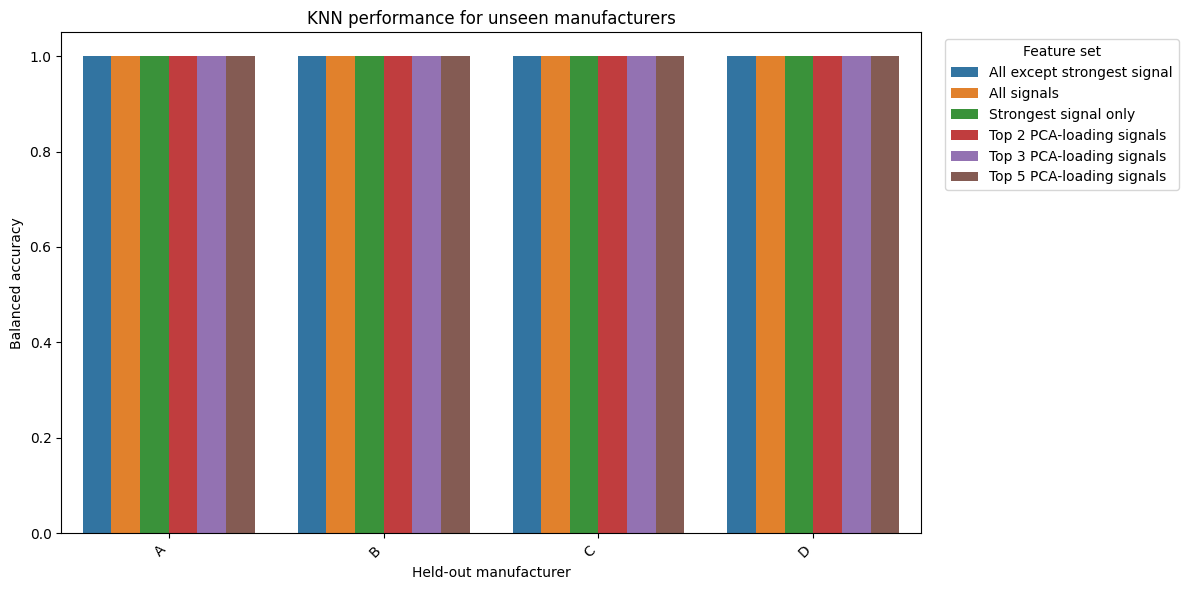

In [49]:
plt.figure(figsize=(12, 6))

sns.barplot(data=manufacturer_performance, x="held_out_manufacturer", 
            y="balanced_accuracy", hue="feature_set")

plt.ylim(0, 1.05)
plt.xlabel("Held-out manufacturer")
plt.ylabel("Balanced accuracy")
plt.title("KNN performance for unseen manufacturers")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Feature set", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 8.7 Compare full and reduced NMR feature sets

The following table summarizes mean performance across all held-out manufacturers. It directly addresses whether five, three, two or one signal can preserve the predictive information contained in the full NMR profile.

In [54]:
feature_set_summary = (
    fold_results
    .groupby(["feature_set", "number_of_features"], as_index=False)
    .agg(
        manufacturers_tested=("held_out_manufacturer", "nunique"),
        mean_accuracy=("accuracy", "mean"),
        std_accuracy=("accuracy", "std"),
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        std_balanced_accuracy=("balanced_accuracy", "std"),
        mean_macro_f1=("macro_f1", "mean")
    )
    .sort_values(
        ["number_of_features", "feature_set"],
        ascending=[False, True]
    )
)

numeric_summary_columns = [
    "mean_accuracy",
    "std_accuracy",
    "mean_balanced_accuracy",
    "std_balanced_accuracy",
    "mean_macro_f1"
]

feature_set_summary[numeric_summary_columns] = (
    feature_set_summary[numeric_summary_columns].round(3)
)

feature_set_summary

,feature_set,number_of_features,manufacturers_tested,mean_accuracy,std_accuracy,mean_balanced_accuracy,std_balanced_accuracy,mean_macro_f1
1,All signals,22,4,1.0,0.0,1.0,0.0,1.0
0,All except strongest signal,21,4,1.0,0.0,1.0,0.0,1.0
5,Top 5 PCA-loading signals,5,4,1.0,0.0,1.0,0.0,1.0
4,Top 3 PCA-loading signals,3,4,1.0,0.0,1.0,0.0,1.0
3,Top 2 PCA-loading signals,2,4,1.0,0.0,1.0,0.0,1.0
2,Strongest signal only,1,4,1.0,0.0,1.0,0.0,1.0


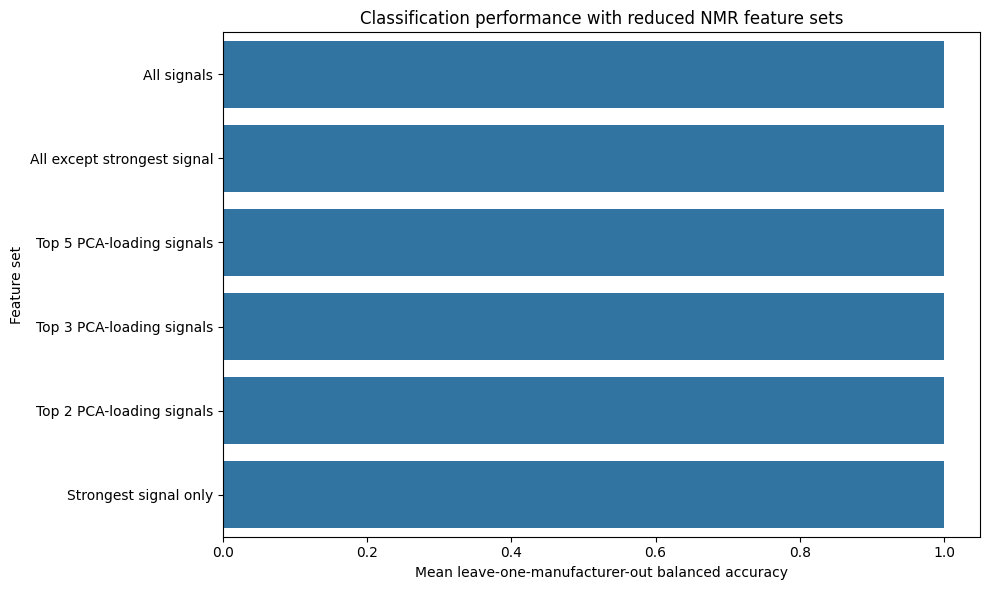

In [55]:
plt.figure(figsize=(10, 6))

plot_summary = (feature_set_summary .sort_values("mean_balanced_accuracy", ascending=True))

sns.barplot(data=plot_summary, x="mean_balanced_accuracy", y="feature_set")

plt.xlim(0, 1.05)
plt.xlabel("Mean leave-one-manufacturer-out " "balanced accuracy")
plt.ylabel("Feature set")
plt.title("Classification performance with reduced " "NMR feature sets")
plt.tight_layout()
plt.show()

### 8.8 Which signals are repeatedly selected?

Because feature ranking is performed separately in each training fold, the selected signals may differ depending on which manufacturer is held out. The frequency table shows which variables are most consistently selected among the top five.

In [56]:
top_five_frequency = (selected_features_logo[selected_features_logo["feature_set"] == 
                                             "Top 5 PCA-loading signals"] 
                                              .groupby("NMR_variable") 
                                              .agg(selection_count=("held_out_manufacturer",
    "nunique"), mean_rank=("feature_rank", "mean"))
                      .sort_values(["selection_count", "mean_rank"], 
                       ascending=[False, True]) 
                      .reset_index())

top_five_frequency["mean_rank"] = top_five_frequency["mean_rank"].round(2)

top_five_frequency

,NMR_variable,selection_count,mean_rank
0,0.89 ppm,4,1.0
1,4.29 ppm,4,2.0
2,4.14 ppm,4,3.5
3,5.26 ppm,4,3.5
4,1.31 ppm,2,5.0
5,1.68 ppm,1,5.0
6,2.31 ppm,1,5.0


### 8.9 Does classification depend on one dominant signal?

Three results are compared:

- `Strongest signal only`: tests whether one signal alone is sufficient.
- `All signals`: provides the full-profile reference.
- `All except strongest signal`: tests whether removing the dominant training signal reduces performance.

If performance remains high after removing the strongest signal, class information is distributed across multiple NMR variables rather than depending on a single marker.

In [57]:
dominant_signal_comparison = (feature_set_summary[feature_set_summary["feature_set"]
                                                  .isin(["Strongest signal only",
    "All signals", "All except strongest signal"])] 
    .copy() 
    .sort_values("mean_balanced_accuracy", ascending=False))

dominant_signal_comparison

,feature_set,number_of_features,manufacturers_tested,mean_accuracy,std_accuracy,mean_balanced_accuracy,std_balanced_accuracy,mean_macro_f1
1,All signals,22,4,1.0,0.0,1.0,0.0,1.0
0,All except strongest signal,21,4,1.0,0.0,1.0,0.0,1.0
2,Strongest signal only,1,4,1.0,0.0,1.0,0.0,1.0


In [58]:
strongest_signal_by_fold = (fold_results[["held_out_manufacturer",
    "strongest_training_signal"]] .drop_duplicates() .sort_values("held_out_manufacturer") .reset_index(drop=True))

strongest_signal_by_fold

,held_out_manufacturer,strongest_training_signal
0,A,0.89 ppm
1,B,0.89 ppm
2,C,0.89 ppm
3,D,0.89 ppm


### 8.10 Confusion matrix for the full NMR profile

Predictions from all leave-one-manufacturer-out folds are pooled to summarize classification using the complete set of NMR signals.

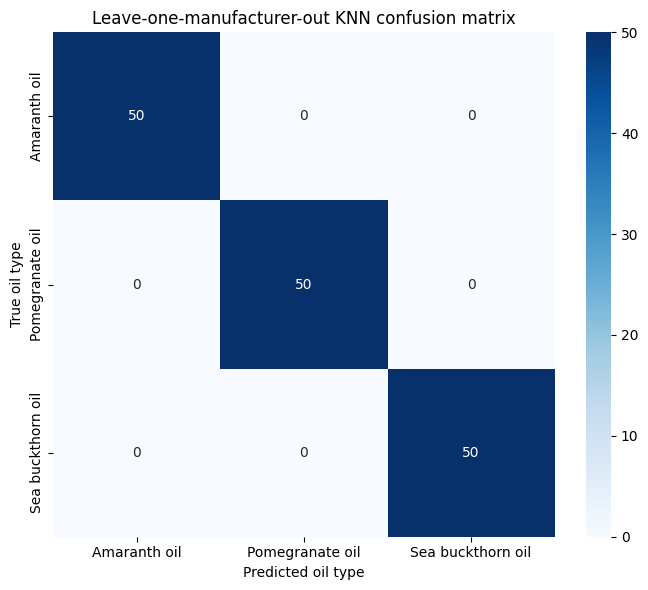

                   precision    recall  f1-score   support

     Amaranth oil       1.00      1.00      1.00        50
  Pomegranate oil       1.00      1.00      1.00        50
Sea buckthorn oil       1.00      1.00      1.00        50

         accuracy                           1.00       150
        macro avg       1.00      1.00      1.00       150
     weighted avg       1.00      1.00      1.00       150



In [59]:
full_profile_predictions = (predictions_logo[predictions_logo["feature_set"] == "All signals"] .copy())

class_names = sorted(y_knn.unique())

full_profile_cm = confusion_matrix(full_profile_predictions["true_oil_type"], 
                                   full_profile_predictions["predicted_oil_type"], 
                                   labels=class_names)

plt.figure(figsize=(7, 6))

sns.heatmap(full_profile_cm, annot=True, fmt="d", 
            xticklabels=class_names,
            yticklabels=class_names, 
            cmap="Blues")

plt.xlabel("Predicted oil type")
plt.ylabel("True oil type")
plt.title("Leave-one-manufacturer-out KNN " "confusion matrix")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "knn_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

print(classification_report(full_profile_predictions["true_oil_type"], 
                            full_profile_predictions["predicted_oil_type"], 
                            zero_division=0))

### 8.11 Interpretation guide

Use the results to answer the three study questions:

- **Generalization across manufacturers:** compare balanced accuracy for each held-out manufacturer. Lower performance for one manufacturer may indicate a distinct spectral profile or stronger within-manufacturer variation.
- **Minimum informative signal set:** compare all signals with the top 5, top 3, top 2 and strongest-signal-only models. Similar performance with fewer variables suggests that a small group of NMR signals contains most of the class information.
- **Dependence on one dominant signal:** compare `All signals` with `All except strongest signal`. A small decrease indicates distributed spectral information; a large decrease indicates strong dependence on one marker.

A perfect score should be described as performance on this specific dataset and validation design, not as universal accuracy for arbitrary oils, manufacturers or measurement conditions.

## 9. Summary

This notebook used NMR intensities to:

- identify signals that differ among oil types,
- inspect signal distributions and relationships,
- reduce dimensionality with PCA,
- interpret score plots, loadings and a biplot,
- evaluate unsupervised grouping with K-means,
- test KNN classification on manufacturers excluded from training,
- compare full and reduced NMR feature sets,
- assess whether classification depends on one dominant signal.

The supervised section uses leave-one-manufacturer-out validation. Imputation, scaling, PCA-based feature ranking and model tuning are fitted without access to the held-out manufacturer.